In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
import scipy as sp
from joblib import Parallel, delayed
import pandas as pd
import itertools
from qutip.qip.operations import rz, cz_gate, cnot, rx, hadamard_transform

In [4]:
cz_se= pd.read_csv('data/data_cz_3ncut_truc1=300_select.txt')
cz= pd.read_csv('data/data_cz_3ncut_truc1=300.txt')
# cz_abs_se= pd.read_csv('data/data_cz_3ncut_truc1=300_abs_select.txt')
# cz_abs= pd.read_csv('data/data_cz_3ncut_truc1=300_abs.txt')
# params = cz_3ncut_se.to_numpy()[[0, 5, 10, 15, 20, 25, 30],:]
# cz_old = pd.read_csv('data/data_fig/data_cz_n2_20.txt')
# pa = np.column_stack((cz_3ncut_se.to_numpy(), np.round(f_noise_9_2us, 8), np.round(f_noise_100_5us, 8), np.round(f_noise_100_50us, 8), np.round(f_ideal_70, 8)))
# df = pd.DataFrame(pa, columns=['tg', 'drive_amp', 'detune', 'f_300_200_True',
#                                'f_300_1000_True', 'f_noise_9_2us', 'f_noise_100_5us', 'f_noise_100_50us', 'f_ideal_70'])
# df.to_csv('data/data_cz_3ncut_truc1=300_select.txt', sep=',', index=False, header=True)

### CZ Infidelity convergence on truncation

max_step=1e-4

In [35]:
tg_list = [32, 74, 116, 158, 200]  # Select the first row for testing
f_ideal_1000 = np.array([
-0.4021448542569617, -1.322630044450615, -2.8292207939498746, -3.5275890997936 ,
-3.949321454120114 ,
])
f_ideal_500 = np.array([
-0.4019024311954381, -1.3225689542270946, -2.8290068464858975, -3.527383190402311 ,
-3.9490553958799968 ,
])
f_ideal_200 = np.array([
-0.40231840173270494, -1.3215409903668713, -2.834576276147882, -3.536724638506567 ,
-3.948964223504374 ,
])
f_ideal_100 = np.array([
-0.4115791900644499, -1.3198497484563945, -2.942236121065928, -3.5852211042087814 ,
-3.9385615217377574 ,
])
f_ideal_55 = np.array([
-0.45025287595319985, -1.3257510272715618, -2.964305513310644, -3.619544687982036 ,
-3.9477218664684277 ,
])
f_ideal_50 = np.array([
-0.3655405764342905, -1.1979709249154762, -2.6552301504055555, -3.3251147403994836 ,
-3.7585441100976005 ,
])
truc = [50, 100, 200, 500, 1000]
f_ideal_1e4 = np.column_stack((f_ideal_50, f_ideal_100, f_ideal_200, f_ideal_500, f_ideal_1000))

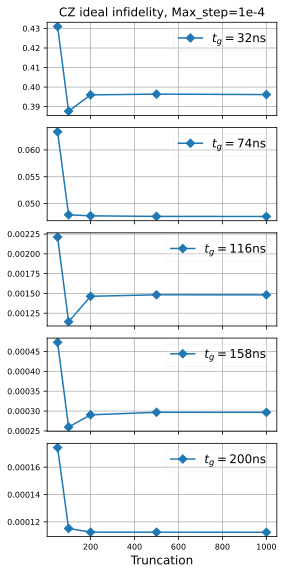

In [43]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(truc, 10**f_ideal_1e4[i], 'D-', label=fr'$t_g = {tg_list[i]:.0f}$ns')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    # ax[i].set_ylabel(fr'$t_g = {params[:,0][i]:.0f}$ns')
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Max_step=1e-4', fontsize=12)
plt.tight_layout()

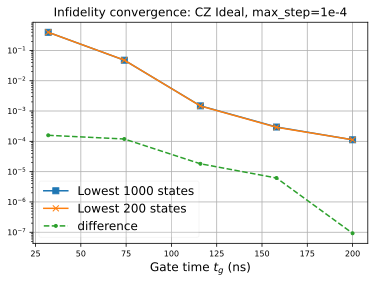

In [23]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_1000, 's-',  label=r'Lowest 1000 states')
ax.plot(tg_list, 10**f_ideal_200, 'x-',  label=r'Lowest 200 states')
ax.plot(tg_list, np.abs(10**f_ideal_200 - 10**f_ideal_1000), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity convergence: CZ Ideal, max_step=1e-4', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

### CZ Infidelity convergence on truncation

max_step=1e-4

In [ ]:
f_ideal_200_1e5 = np.array([
-0.4023161488683899, -1.3215325536747542, -2.8343721116070513, -3.5363062407409918 ,
-3.9482128398840417 ,
])
f_ideal_200_3e5 = np.array([
-0.4023186495398163, -1.3215413049625668, -2.8345785926941276, -3.5365859520988754 ,
-3.948371500612083 ,
])
f_ideal_200_1e4 = np.array([
-0.40231840173270494, -1.3215409903668713, -2.834576276147882, -3.536724638506567 ,
-3.948964223504374 ,
])
f_ideal_200_3e4 = np.array([
-0.40232050742139436, -1.3216231178376339, -2.8345927980588455, -3.536830191797218 ,
-3.949097966559681 ,
])
f_ideal_200_1e3 = np.array([
-0.4022920793018655, -1.3215751413387333, -2.8345692209828206, -3.5365915050345276 ,
-3.9489747294329547 ,
])
f_ideal_1000_1e3 = np.array([
-0.40215530875591887, -1.3226609064874149, -2.8283848283603117, -3.5222117329875666 ,
-3.9493951402836407 ,
])
msteps = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3]
f_ideal_200 = np.column_stack((f_ideal_200_1e5, f_ideal_200_3e5, f_ideal_200_1e4, 
                               f_ideal_200_3e4, f_ideal_200_1e3))

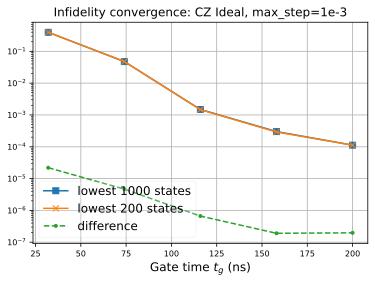

In [42]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_1000_1e3, 's-',  label=r'lowest 1000 states')
ax.plot(tg_list, 10**f_ideal_200_1e3, 'x-',  label=r'lowest 200 states')
# ax.plot(tg_list, 10**f_ideal_200_1e4, 'x-',  label=r'max_step=1e-4')
ax.plot(tg_list, np.abs(10**f_ideal_200_1e5 - 10**f_ideal_200_1e3), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity convergence: CZ Ideal, max_step=1e-3', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

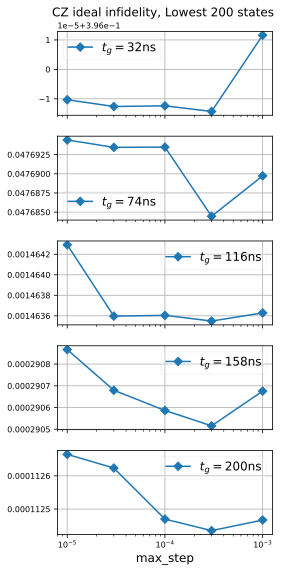

In [34]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(msteps, 10**f_ideal_200[i], 'D-', label=fr'$t_g = {tg_list[i]:.0f}$ns')
    ax[i].set_xscale('log')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    # ax[i].set_ylabel(fr'$t_g = {params[:,0][i]:.0f}$ns')
ax[4].set_xlabel('max_step', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Lowest 200 states ', fontsize=12)
plt.tight_layout()

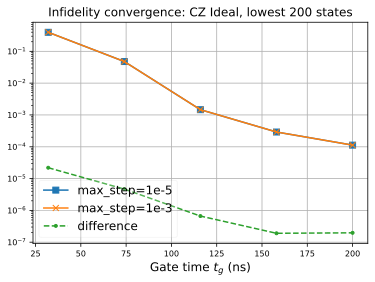

In [27]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_200_1e5, 's-',  label=r'max_step=1e-5')
ax.plot(tg_list, 10**f_ideal_200_1e3, 'x-',  label=r'max_step=1e-3')
# ax.plot(tg_list, 10**f_ideal_200_1e4, 'x-',  label=r'max_step=1e-4')
ax.plot(tg_list, np.abs(10**f_ideal_200_1e5 - 10**f_ideal_200_1e3), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity convergence: CZ Ideal, lowest 200 states', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [ ]:
=

In [8]:
f_55_v1 = np.array([
-0.51058425, -0.45027587, -1.1631009, -1.0196655 ,
-1.20500978, -1.65278366, -2.94062418, -2.18141001 ,
-2.96547247, -2.98523823, -3.32352219, -3.38020187 ,
-3.81762752, -4.15723917, -4.27838382, -3.93696774 ,

-1.16907875, -1.0541898, -1.32455384, -2.2778143 ,
-2.40315738, -2.45116251, -3.11621851, -3.12026717 ,
-3.32732425, -3.61113041, -3.92939783, -4.37570773 ,
-4.11258268 ,
])

f_55_170us_v1  = np.array([
-0.51070743, -0.45019765, -1.16304168, -1.01983804 ,
-1.20528484, -1.64859555, -2.8892864, -2.17202251 ,
-2.90767332, -2.92552015, -3.19619888, -3.23174844 ,
-3.47840926, -3.57894739, -3.58480594, -3.4773306 ,

-1.16918318, -1.05436901, -1.32491647, -2.26298383 ,
-2.39064559, -2.43166511, -3.03847768, -3.03664572 ,
-3.19898209, -3.37524209, -3.51510295, -3.61610324 ,
-3.53946891 ,
])
pa_55_v1 = np.array([
[20.032421, 0.045974, 0.029778] ,
[32.034226, 0.037135, 0.016167] ,
[44.031495, 0.031706, 0.024911] ,
[56.077009, 0.022808, 0.026791] ,
[68.037311, 0.018268, 0.01604] ,
[80.069609, 0.021699, 0.026059] ,
[91.950393, 0.01767, 0.02547] ,
[104.067706, 0.014971, 0.022579] ,
[116.077689, 0.013154, 0.020213] ,
[127.98519, 0.011742, 0.018634] ,
[140.02276, 0.010556, 0.017] ,
[151.988898, 0.009603, 0.015713] ,
[164.015275, 0.008802, 0.014578] ,
[176.001029, 0.008127, 0.01359] ,
[188.007783, 0.007544, 0.012719] ,
[199.99317, 0.007039, 0.011975] ,

[50.066456, 0.027173, 0.026765] ,
[62.054606, 0.02093, 0.017519] ,
[74.049203, 0.016254, 0.014905] ,
[86.106856, 0.019481, 0.02577] ,
[97.920015, 0.016221, 0.0249] ,
[110.011766, 0.014013, 0.021038] ,
[121.908197, 0.012432, 0.019475] ,
[134.043513, 0.011113, 0.017721] ,
[146.02291, 0.010066, 0.016405] ,
[158.038459, 0.009186, 0.015116] ,
[170.005964, 0.008453, 0.014067] ,
[182.00291, 0.007825, 0.013145] ,
[193.995576, 0.007283, 0.012342] ,
])
pa = np.column_stack((pa_55_v1, f_55_v1, f_55_170us_v1))
for i in range(len(pa)):
    print(pa[i].tolist(), ',')

[20.032421, 0.045974, 0.029778, -0.51058425, -0.51070743] ,
[32.034226, 0.037135, 0.016167, -0.45027587, -0.45019765] ,
[44.031495, 0.031706, 0.024911, -1.1631009, -1.16304168] ,
[56.077009, 0.022808, 0.026791, -1.0196655, -1.01983804] ,
[68.037311, 0.018268, 0.01604, -1.20500978, -1.20528484] ,
[80.069609, 0.021699, 0.026059, -1.65278366, -1.64859555] ,
[91.950393, 0.01767, 0.02547, -2.94062418, -2.8892864] ,
[104.067706, 0.014971, 0.022579, -2.18141001, -2.17202251] ,
[116.077689, 0.013154, 0.020213, -2.96547247, -2.90767332] ,
[127.98519, 0.011742, 0.018634, -2.98523823, -2.92552015] ,
[140.02276, 0.010556, 0.017, -3.32352219, -3.19619888] ,
[151.988898, 0.009603, 0.015713, -3.38020187, -3.23174844] ,
[164.015275, 0.008802, 0.014578, -3.81762752, -3.47840926] ,
[176.001029, 0.008127, 0.01359, -4.15723917, -3.57894739] ,
[188.007783, 0.007544, 0.012719, -4.27838382, -3.58480594] ,
[199.99317, 0.007039, 0.011975, -3.93696774, -3.4773306] ,
[50.066456, 0.027173, 0.026765, -1.16907875, 

In [9]:
f_55_v1 = np.array([
-0.68353533, -0.59883559, -1.01265097 ,
-2.9428149 ,
-0.34125657, -0.40675598,
])

f_55_170us_v1  = np.array([
-0.6833774, -0.59860058, -1.01226914 ,
-2.88397778 ,
-0.34127759, -0.40670604
])
pa_55_v1 = np.array([
[20.032421, 0.045974, 0.029778] ,
[38.046441, 0.035323, 0.021612] ,
[44.031495, 0.031706, 0.024911] ,
[116.077689, 0.013154, 0.020213] ,
[26.095773, 0.03827, 0.034993] ,
[32.034226, 0.037135, 0.016167] ,
])
pa = np.column_stack((pa_55_v1, f_55_v1, f_55_170us_v1))
for i in range(len(pa)):
    print(pa[i].tolist(), ',')

[20.032421, 0.045974, 0.029778, -0.68353533, -0.6833774] ,
[38.046441, 0.035323, 0.021612, -0.59883559, -0.59860058] ,
[44.031495, 0.031706, 0.024911, -1.01265097, -1.01226914] ,
[116.077689, 0.013154, 0.020213, -2.9428149, -2.88397778] ,
[26.095773, 0.03827, 0.034993, -0.34125657, -0.34127759] ,
[32.034226, 0.037135, 0.016167, -0.40675598, -0.40670604] ,


In [11]:
arr = np.array([
[20.032421, 0.045974, 0.029778, -0.68353533, -0.6833774] ,
[26.095773, 0.03827, 0.034993, -0.34125657, -0.34127759] ,
[32.034226, 0.037135, 0.016167, -0.40675598, -0.40670604] ,
[38.046441, 0.035323, 0.021612, -0.59883559, -0.59860058] ,
[44.031495, 0.031706, 0.024911, -1.01265097, -1.01226914] ,
[56.077009, 0.022808, 0.026791, -1.0196655, -1.01983804] ,
[68.037311, 0.018268, 0.01604, -1.20500978, -1.20528484] ,
[80.069609, 0.021699, 0.026059, -1.65278366, -1.64859555] ,
[91.950393, 0.01767, 0.02547, -2.94062418, -2.8892864] ,
[104.067706, 0.014971, 0.022579, -2.18141001, -2.17202251] ,
[116.077689, 0.013154, 0.020213, -2.9428149, -2.88397778] ,
[127.98519, 0.011742, 0.018634, -2.98523823, -2.92552015] ,
[140.02276, 0.010556, 0.017, -3.32352219, -3.19619888] ,
[151.988898, 0.009603, 0.015713, -3.38020187, -3.23174844] ,
[164.015275, 0.008802, 0.014578, -3.81762752, -3.47840926] ,
[176.001029, 0.008127, 0.01359, -4.15723917, -3.57894739] ,
[188.007783, 0.007544, 0.012719, -4.27838382, -3.58480594] ,
[199.99317, 0.007039, 0.011975, -3.93696774, -3.4773306] ,
[50.066456, 0.027173, 0.026765, -1.16907875, -1.16918318] ,
[62.054606, 0.02093, 0.017519, -1.0541898, -1.05436901] ,
[74.049203, 0.016254, 0.014905, -1.32455384, -1.32491647] ,
[86.106856, 0.019481, 0.02577, -2.2778143, -2.26298383] ,
[97.920015, 0.016221, 0.0249, -2.40315738, -2.39064559] ,
[110.011766, 0.014013, 0.021038, -2.45116251, -2.43166511] ,
[121.908197, 0.012432, 0.019475, -3.11621851, -3.03847768] ,
[134.043513, 0.011113, 0.017721, -3.12026717, -3.03664572] ,
[146.02291, 0.010066, 0.016405, -3.32732425, -3.19898209] ,
[158.038459, 0.009186, 0.015116, -3.61113041, -3.37524209] ,
[170.005964, 0.008453, 0.014067, -3.92939783, -3.51510295] ,
[182.00291, 0.007825, 0.013145, -4.37570773, -3.61610324] ,
[193.995576, 0.007283, 0.012342, -4.11258268, -3.53946891] ,
])
sorted_arr = arr[np.argsort(arr[:, 0])]
sorted_arr
for i in range(len(sorted_arr)):
    print(sorted_arr[i].tolist(), ',')

len(sorted_arr)

[20.032421, 0.045974, 0.029778, -0.68353533, -0.6833774] ,
[26.095773, 0.03827, 0.034993, -0.34125657, -0.34127759] ,
[32.034226, 0.037135, 0.016167, -0.40675598, -0.40670604] ,
[38.046441, 0.035323, 0.021612, -0.59883559, -0.59860058] ,
[44.031495, 0.031706, 0.024911, -1.01265097, -1.01226914] ,
[50.066456, 0.027173, 0.026765, -1.16907875, -1.16918318] ,
[56.077009, 0.022808, 0.026791, -1.0196655, -1.01983804] ,
[62.054606, 0.02093, 0.017519, -1.0541898, -1.05436901] ,
[68.037311, 0.018268, 0.01604, -1.20500978, -1.20528484] ,
[74.049203, 0.016254, 0.014905, -1.32455384, -1.32491647] ,
[80.069609, 0.021699, 0.026059, -1.65278366, -1.64859555] ,
[86.106856, 0.019481, 0.02577, -2.2778143, -2.26298383] ,
[91.950393, 0.01767, 0.02547, -2.94062418, -2.8892864] ,
[97.920015, 0.016221, 0.0249, -2.40315738, -2.39064559] ,
[104.067706, 0.014971, 0.022579, -2.18141001, -2.17202251] ,
[110.011766, 0.014013, 0.021038, -2.45116251, -2.43166511] ,
[116.077689, 0.013154, 0.020213, -2.9428149, -2.883

31

In [14]:
cz_se['f_truc55_170us'].to_numpy() == sorted_arr[:, 4]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [16]:
df = cz_se
headers = df.columns

# Convert to a list if you prefer
headers_list = df.columns.tolist()

print(headers)
print(headers_list)

Index(['tg', 'drive_amp', 'detune', 'f_200_select', 'f_1000_False',
       'f_truc55_170us', 'f_truc55_30us', 'f_truc55_3us', 'f_truc55_ideal'],
      dtype='object')
['tg', 'drive_amp', 'detune', 'f_200_select', 'f_1000_False', 'f_truc55_170us', 'f_truc55_30us', 'f_truc55_3us', 'f_truc55_ideal']


In [10]:
f_170us = np.array([
-0.5436354, -0.34127759, -0.40670604, -0.67118499 ,
-1.01439291 ,

-1.01983804 ,
-1.20528484, -1.64859555, -2.8892864, -2.17202251 ,
-2.90767332, -2.92552015, -3.19619888, -3.23174844 ,
-3.47840926, -3.57894739, -3.58480594, -3.4773306 ,
                ])
f_30us = np.array([
-0.54355239, -0.34116252, -0.40652297, -0.67059589 ,
-1.01306228 ,

-1.01864572 ,
-1.20290963, -1.63907376, -2.75460551, -2.14231406 ,
-2.75722712, -2.76320537, -2.91529435, -2.91900961 ,
-3.00249664, -3.01299545, -2.99420581, -2.94607236 ,
                ])
f_3us = np.array([
-0.54177303, -0.33982723, -0.40448073, -0.66407211 ,
-0.99845167 ,

-1.00563781 ,
-1.17752383, -1.54674489, -2.16120076, -1.90572615 ,
-2.1338429, -2.11924113, -2.12374602, -2.10077456 ,
-2.08744899, -2.064198, -2.03822716, -2.01069381 ,
                ])

p1 = np.array([
[20.032421, 0.045974, 0.029778] ,
[26.095773, 0.03827, 0.034993] ,
[32.034226, 0.037135, 0.016167] ,
[38.046441, 0.035323, 0.021612] ,
[44.031495, 0.031706, 0.024911] ,


[56.077009, 0.022808, 0.026791] ,
[68.037311, 0.018268, 0.01604] ,
[80.069609, 0.021699, 0.026059] ,
[91.950393, 0.01767, 0.02547] ,
[104.067706, 0.014971, 0.022579] ,
[116.077689, 0.013154, 0.020213] ,
[127.98519, 0.011742, 0.018634] ,
[140.02276, 0.010556, 0.017] ,
[151.988898, 0.009603, 0.015713] ,
[164.015275, 0.008802, 0.014578] ,
[176.001029, 0.008127, 0.01359] ,
[188.007783, 0.007544, 0.012719] ,
[199.99317, 0.007039, 0.011975] ,
])
f_170us_2 = np.array([
-1.16918318, -1.05436901, -1.32491647, -2.26298383 ,
-2.39064559, -2.43166511, -3.03847768, -3.03664572 ,
-3.19898209, -3.37524209, -3.51510295, -3.61610324 ,
-3.53946891 ,
                ])
f_30us_2 = np.array([
-1.16744777, -1.05285794, -1.32154718, -2.22584753 ,
-2.34480924, -2.37653541, -2.84234521, -2.83005178 ,
-2.9107925, -2.97396132, -3.00453185, -3.01243948 ,
-2.97287236 ,
                ])
f_3us_2 = np.array([
-1.14839592, -1.03641974, -1.28612319, -1.94789079 ,
-2.02269741, -2.01407813, -2.14582291, -2.12012546 ,
-2.11291936, -2.09603045, -2.07539049, -2.05219123 ,
-2.02484986 ,
                ])

p2 = np.array([
[50.066456, 0.027173, 0.026765] ,
[62.054606, 0.02093, 0.017519] ,
[74.049203, 0.016254, 0.014905] ,
[86.106856, 0.019481, 0.02577] ,
[97.920015, 0.016221, 0.0249] ,
[110.011766, 0.014013, 0.021038] ,
[121.908197, 0.012432, 0.019475] ,
[134.043513, 0.011113, 0.017721] ,
[146.02291, 0.010066, 0.016405] ,
[158.038459, 0.009186, 0.015116] ,
[170.005964, 0.008453, 0.014067] ,
[182.00291, 0.007825, 0.013145] ,
[193.995576, 0.007283, 0.012342] ,
])

c1 = np.column_stack((p1, f_170us, f_30us, f_3us))
c2 = np.column_stack((p2, f_170us_2, f_30us_2, f_3us_2))
arr = np.row_stack((c1,c2))
sorted_arr = arr[np.argsort(arr[:, 0])]
sorted_arr
for i in range(len(sorted_arr)):
    print(sorted_arr[i].tolist(), ',')

[20.032421, 0.045974, 0.029778, -0.5436354, -0.54355239, -0.54177303] ,
[26.095773, 0.03827, 0.034993, -0.34127759, -0.34116252, -0.33982723] ,
[32.034226, 0.037135, 0.016167, -0.40670604, -0.40652297, -0.40448073] ,
[38.046441, 0.035323, 0.021612, -0.67118499, -0.67059589, -0.66407211] ,
[44.031495, 0.031706, 0.024911, -1.01439291, -1.01306228, -0.99845167] ,
[50.066456, 0.027173, 0.026765, -1.16918318, -1.16744777, -1.14839592] ,
[56.077009, 0.022808, 0.026791, -1.01983804, -1.01864572, -1.00563781] ,
[62.054606, 0.02093, 0.017519, -1.05436901, -1.05285794, -1.03641974] ,
[68.037311, 0.018268, 0.01604, -1.20528484, -1.20290963, -1.17752383] ,
[74.049203, 0.016254, 0.014905, -1.32491647, -1.32154718, -1.28612319] ,
[80.069609, 0.021699, 0.026059, -1.64859555, -1.63907376, -1.54674489] ,
[86.106856, 0.019481, 0.02577, -2.26298383, -2.22584753, -1.94789079] ,
[91.950393, 0.01767, 0.02547, -2.8892864, -2.75460551, -2.16120076] ,
[97.920015, 0.016221, 0.0249, -2.39064559, -2.34480924, -2.

In [12]:
sorted_arr = np.array([
[20.032421, 0.045974, 0.029778, -0.6833774, -0.68314548,-0.68084056,] ,
[26.095773, 0.03827, 0.034993, -0.34127759, -0.34116252, -0.33982723] ,
[32.034226, 0.037135, 0.016167, -0.40670604, -0.40652297, -0.40448073] ,
[38.046441, 0.035323, 0.021612, -0.59860058, -0.59822651,-0.59405037,] ,
[44.031495, 0.031706, 0.024911,  -1.01226914 ,-1.01110022,-0.99789514,] ,
[50.066456, 0.027173, 0.026765, -1.16918318, -1.16744777, -1.14839592] ,
[56.077009, 0.022808, 0.026791, -1.01983804, -1.01864572, -1.00563781] ,
[62.054606, 0.02093, 0.017519, -1.05436901, -1.05285794, -1.03641974] ,
[68.037311, 0.018268, 0.01604, -1.20528484, -1.20290963, -1.17752383] ,
[74.049203, 0.016254, 0.014905, -1.32491647, -1.32154718, -1.28612319] ,
[80.069609, 0.021699, 0.026059, -1.64859555, -1.63907376, -1.54674489] ,
[86.106856, 0.019481, 0.02577, -2.26298383, -2.22584753, -1.94789079] ,
[91.950393, 0.01767, 0.02547, -2.8892864, -2.75460551, -2.16120076] ,
[97.920015, 0.016221, 0.0249, -2.39064559, -2.34480924, -2.02269741] ,
[104.067706, 0.014971, 0.022579, -2.17202251, -2.14231406, -1.90572615] ,
[110.011766, 0.014013, 0.021038, -2.43166511, -2.37653541, -2.01407813] ,
[116.077689, 0.013154, 0.020213, -2.88397778 , -2.74072707 ,-2.12990286 ,] ,
[121.908197, 0.012432, 0.019475, -3.03847768, -2.84234521, -2.14582291] ,
[127.98519, 0.011742, 0.018634, -2.92552015, -2.76320537, -2.11924113] ,
[134.043513, 0.011113, 0.017721, -3.03664572, -2.83005178, -2.12012546] ,
[140.02276, 0.010556, 0.017, -3.19619888, -2.91529435, -2.12374602] ,
[146.02291, 0.010066, 0.016405, -3.19898209, -2.9107925, -2.11291936] ,
[151.988898, 0.009603, 0.015713, -3.23174844, -2.91900961, -2.10077456] ,
[158.038459, 0.009186, 0.015116, -3.37524209, -2.97396132, -2.09603045] ,
[164.015275, 0.008802, 0.014578, -3.47840926, -3.00249664, -2.08744899] ,
[170.005964, 0.008453, 0.014067, -3.51510295, -3.00453185, -2.07539049] ,
[176.001029, 0.008127, 0.01359, -3.57894739, -3.01299545, -2.064198] ,
[182.00291, 0.007825, 0.013145, -3.61610324, -3.01243948, -2.05219123] ,
[188.007783, 0.007544, 0.012719, -3.58480594, -2.99420581, -2.03822716] ,
[193.995576, 0.007283, 0.012342, -3.53946891, -2.97287236, -2.02484986] ,
[199.99317, 0.007039, 0.011975, -3.4773306, -2.94607236, -2.01069381] ,
])

In [17]:
cz_se['f_truc55_170us'] = sorted_arr[:, 3]
cz_se['f_truc55_30us'] = sorted_arr[:, 4]
cz_se['f_truc55_3us'] = sorted_arr[:, 5]
cz_se.to_csv('data/data_cz_3ncut_truc1=300_select.txt', sep=',', index=False, header=True)

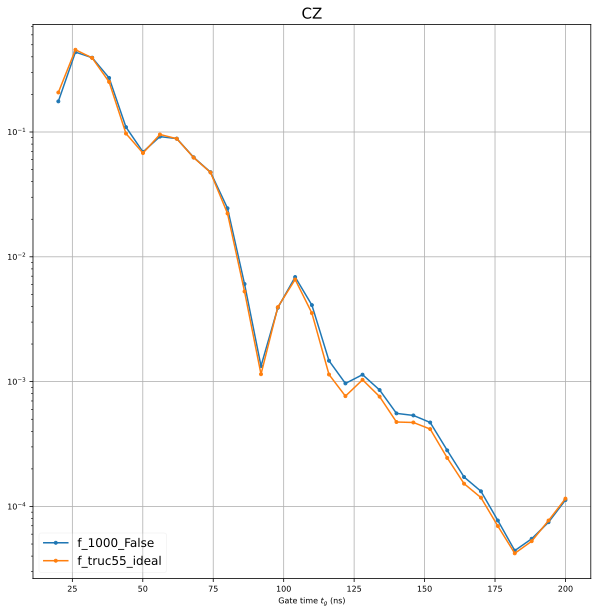

In [25]:
fig, ax = plt.subplots(figsize=(10,10))
ms = 4
# ax.plot(cz['tg'], 10**cz['f_1000_False'], '-',  label=r'fidelity')
ax.plot(cz_se['tg'], 10**cz_se['f_1000_False'], '.-',  label=r'f_1000_False')
ax.plot(cz_se['tg'], 10**cz_se['f_truc55_ideal'], '.-',  label=r'f_truc55_ideal')
# ax.plot(cz_se['tg'], 10**cz_se['f_truc55_170us'], '.-',  label=r'f_truc55_170us')
# ax.plot(cz_se['tg'], 10**f_55, 'x--',  label=r'f_55')
# plt.plot(cz_se['tg'], 10**sorted_arr[:, 3], 's--', label=r'f_170us', ms=ms)
# plt.plot(cz_se['tg'], 10**sorted_arr[:, 4], 'v--', label=r'f_30us', ms=ms)
# plt.plot(cz_se['tg'], 10**sorted_arr[:, 5], 'D--', label=r'f_3us', ms=ms)
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'CZ', fontsize=15)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

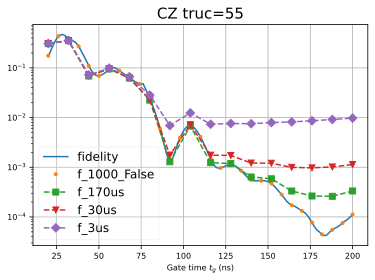

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(cz['tg'], 10**cz['f_1000_False'], '-',  label=r'fidelity')
ax.plot(cz_se['tg'], 10**cz_se['f_1000_False'], '.',  label=r'f_1000_False')
# ax.plot(cz_se['tg'], 10**f_55, 'x--',  label=r'f_55')
plt.plot(cz_se['tg'][::2], 10**f_170us, 's--', label=r'f_170us')
plt.plot(cz_se['tg'][::2], 10**f_30us, 'v--', label=r'f_30us')
plt.plot(cz_se['tg'][::2], 10**f_3us, 'D--', label=r'f_3us')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'CZ truc=55', fontsize=15)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [39]:
f_55 = np.array([
-0.51058425, -0.22928562, -0.45027587, -0.75874943 ,
-1.1631009, -1.16907875, -1.0196655, -1.0541898 ,
-1.20500978, -1.32455384, -1.65278366, -2.2778143 ,
-2.94062418, -2.40315738, -2.18141001, -2.45116251 ,
-2.96547247, -3.11621851, -2.98523823, -3.12026717 ,
-3.32352219, -3.32732425, -3.38020187, -3.61113041 ,
-3.81762752, -3.92939783, -4.15723917, -4.37570773 ,
-4.27838382, -4.11258268, -3.93696774 ,
                ])

f_50 = np.array([
-0.66716357, -0.39800236, -0.39665555, -0.57356839 ,
-0.96789198, -1.22032354, -1.14703548, -1.13332379 ,
-1.29333606, -1.41437754, -1.3049125, -1.76814033 ,
-2.38927731, -2.47494074, -2.12016122, -2.30495668 ,
-2.73246312, -2.91543937, -2.87272424, -2.97457653 ,
-3.1802759, -3.24969593, -3.29213832, -3.48553936 ,
-3.69807913, -3.77777664, -3.96792383, -4.1573679 ,
-4.09352147, -4.03986884, -3.9022418 ,
                ])
f_65 = np.array([
-0.51977315, -0.44970208, -1.16794427, -1.02983215 ,
-1.21444285, -1.6329977, -2.93956907, -2.18163356 ,
-2.96057384, -2.98764397, -3.32667613, -3.38507718 ,
-3.83076511, -4.17401137, -4.28891265, -3.94533543 ,
                ])
f_70 = np.array([
-0.50419239, -0.46222679, -1.15272653, -1.02705281 ,
-1.21462904, -1.63614466, -2.93797066, -2.18176864 ,
-2.96082597, -2.98710101, -3.32535713, -3.38357929 ,
-3.82746148, -4.16993579, -4.28576454, -3.9428276 ,
                ])
f_80 = np.array([
-0.54359954, -0.34125657, -0.40675598, -0.67155256 ,
-1.01508493, -1.15436211, -1.02778402, -1.05774382 ,
-1.20870013, -1.32804133, -1.63056232, -2.24928851 ,
-2.92955373, -2.41294768, -2.18089158, -2.44429117 ,
-2.95309799, -3.11028365, -2.98385768, -3.11744523 ,
-3.32143799, -3.32880889, -3.3798913, -3.60946761 ,
-3.82075798, -3.93276971, -4.16348229, -4.3891968 ,
-4.28972255, -4.12655649, -3.94937036 ,
                ])
f_90 = np.array([
-0.39609544, -0.29785365, -0.35041669, -0.65397913 ,
-0.92148158, -1.05331073, -0.98017391, -1.02479862 ,
-1.17977951, -1.30282378, -1.7101154, -2.33873896 ,
-2.85564092, -2.35599794, -2.17404373, -2.45096468 ,
-2.95291256, -3.09868607, -2.97548843, -3.11326672 ,
-3.31006387, -3.3140761, -3.36913319, -3.59800981 ,
-3.80153601, -3.91577321, -4.14260669, -4.36644802 ,
-4.28367574, -4.11949075, -3.94552987 ,
                ])
f_100 = np.array([
-0.68353533, -0.33710623, -0.41161734, -0.59883559 ,
-1.01265097, -1.15962505, -1.02105351, -1.04991594 ,
-1.19967493, -1.31927063, -1.65179012, -2.2741641 ,
-2.9081207, -2.39577554, -2.17827666, -2.44418554 ,
-2.9428149, -3.08514525, -2.95728008, -3.08143855 ,
-3.28298034, -3.29548544, -3.35712967, -3.58138307 ,
-3.77209854, -3.86926403, -4.08197749, -4.27699199 ,
-4.22881141, -4.10035409, -3.94001187 ,
                ])

f_50_5_10 = np.array([
-0.72976344, -0.27088835, -0.40605082, -0.6589077 ,
-1.17155732, -1.23841884, -1.05211104, -1.07471713 ,
-1.22204141, -1.33926182, -1.59780422, -2.20595315 ,
-2.93361977, -2.43302928, -2.18210769, -2.4387693 ,
-2.93703449, -3.08248166, -2.96210253, -3.09203236 ,
-3.30199145, -3.3279663, -3.38047746, -3.60560642 ,
-3.80304219, -3.89412613, -4.09022557, -4.28879642 ,
-4.22959054, -4.10072762, -3.93710374 ,
                ])





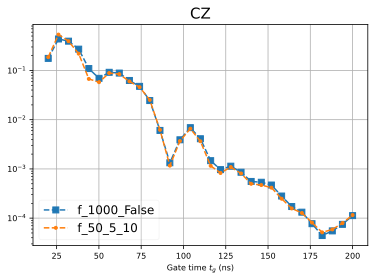

In [41]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(cz_se['tg'], 10**cz_se['f_1000_False'], 's--',  label=r'f_1000_False')
# ax.plot(cz_se['tg'], 10**f_55, '.-',  label=r'f_55')
# ax.plot(cz_se['tg'], 10**f_50, '.-',  label=r'f_50')
# plt.plot(cz_se['tg'][::2], 10**f_65, '.--', label=r'f_65')
# plt.plot(cz_se['tg'][::2], 10**f_70, '.--', label=r'f_70')
# plt.plot(cz_se['tg'], 10**f_80, '.--', label=r'f_80')
# plt.plot(cz_se['tg'], 10**f_90, 'x--', label=r'f_90')
# plt.plot(cz_se['tg'], 10**f_100, '.--', label=r'f_100')
plt.plot(cz_se['tg'], 10**f_50_5_10, '.--', label=r'f_50_5_10')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'CZ', fontsize=15)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [3]:
tg3 = [20, 116, 176]
f_ideal = np.array([-0.75476894, -2.83246852, -4.11260292])
f_9_2us_new_tphit1 = np.array([-0.5021915344230701, -1.6811286402457495, -1.6227621042569589 ,])
f_50_10us_new_tphit1 = np.array([-0.5040189497681088, -2.1990484967738664, -2.2019562401822137 ,])
f_100_50us_new_tphit1 = np.array([-0.5041941407624773, -2.632606997877334, -2.7493368217174954 ,])
f_200_100us_new_tphit1 = np.array([-0.5042371503520402, -2.759057227970106, -3.0178305459657544 ,])
f_300_100us_new_tphit1 = np.array([-0.5042475690696818, -2.7644466986045613, -3.063576775599458 ,])
f_200_200us_new_tphit1 = np.array([-0.5042426999791267, -2.8315978507327055 , -3.1026149804899097 ,])
f_500_500us_new_tphit1 = np.array([-0.5042664831377491, -2.8950792834252983 , -3.5036060052668683 ,])

tg10 = cz_se.to_numpy()[2::3,0]
f_200_100us_new_tphit1_v2 = np.array([
-0.46188786432991025, -1.1789452391515232, -1.2117808518855973, -2.185892826340362 ,
-2.14640827514074, -2.8533319825605927, -2.9426744998258343, -3.0018689555308566 ,
-3.0178305459657544, -2.9409795383149198 ,
])
f_50_10us_new_tphit1_v2 = np.array([
-0.45893214666985493, -1.1369131650603688, -1.185712645333353, -1.8689011803754012 ,
-1.9523078945309564, -2.2277388246984313, -2.244041237062584, -2.2327885791370012 ,
-2.2019562401822137, -2.156538467192805 ,
])
f_9_2us_new_tphit1_v2 = np.array([
-0.4468624282018946, -0.9948360474512556, -1.0980328196596032, -1.4395460463604297 ,
-1.6092342514509008, -1.6967928535585, -1.6992217245063779, -1.6713028223857358 ,
-1.6227621042569589, -1.5669253894861164 ,
])

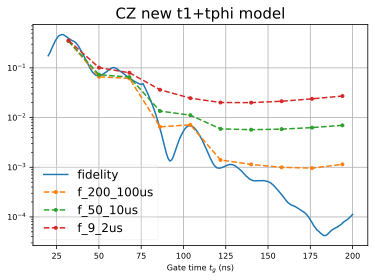

: 

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(cz['tg'], 10**cz['f_1000_False'], '-',  label=r'fidelity')
# ax.plot(tg3, 10**f_ideal, 's',  label=r'f_ideal')
# ax.plot(tg3, 10**f_9_2us_new_tphit1, '.--',  label=r'f_9_2us_new_tphit1')
# ax.plot(tg3, 10**f_50_10us_new_tphit1, 's',  label=r'f_50_10us_new_tphit1')
# ax.plot(tg3, 10**f_100_50us_new_tphit1, '.--',  label=r'f_100_50us_new_tphit1')
# ax.plot(tg3, 10**f_200_100us_new_tphit1, 's',  label=r'f_200_100us_new_tphit1')
# ax.plot(tg3, 10**f_300_100us_new_tphit1, '.--',  label=r'f_300_100us_new_tphit1')
# ax.plot(tg3, 10**f_200_200us_new_tphit1, '.--',  label=r'f_200_200us_new_tphit1')
# ax.plot(tg3, 10**f_500_500us_new_tphit1, '.--',  label=r'f_500_500us_new_tphit1')

ax.plot(tg10, 10**f_200_100us_new_tphit1_v2, '.--',  label=r'f_200_100us')
ax.plot(tg10, 10**f_50_10us_new_tphit1_v2, '.--',  label=r'f_50_10us')
ax.plot(tg10, 10**f_9_2us_new_tphit1_v2, '.--',  label=r'f_9_2us')

plt.yscale('log')
# plt.ylim(3e-7, 6e-1)
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'CZ new t1+tphi', fontsize=15)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [7]:
tg5 = [20, 50, 110, 170, 200]
f_ideal = np.array([
-0.5041923930159149, -1.1837822772719384, -2.4468077600986398, -3.9381314077843563 ,
-3.942827604985377 ,
])
f_2us_100_old = np.array([
-0.49965767637989145, -1.1096575414500924, -1.7092133089982289, -1.7880424922898561 ,
-1.7655355268803512 ,
])
f_2us_100_t1_08 = np.array([
-0.5005056940819379, -0.981204019652748, -1.6068089566964516, -1.6638551696250894 ,
-1.6165210145993723 ,
])
f_2us_100_t1_28 = np.array([
-0.4946796566813144, -1.0039327253328274, -1.4677836869563239, -1.529590879959015 ,
-1.422033231288581 ,
])
f_2us_100_tphi_t1_08 = np.array([
-0.5038654097971111, -1.014200761544578, -1.7902081103192617, -1.8801846048606097 ,
-1.8103275435987978 ,
])
f_2us_100_tphi_t1_28 = np.array([
-0.4977278130380916, -1.034612069627661, -1.5997508020593683, -1.685571949385087 ,
-1.6606436071393158 ,
])
f_2us_100_tphi = np.array([
-0.502809360036335, -1.157283839692544, -2.0528469733581494, -2.2984003812230798 ,
-2.2682615649992894 ,
])

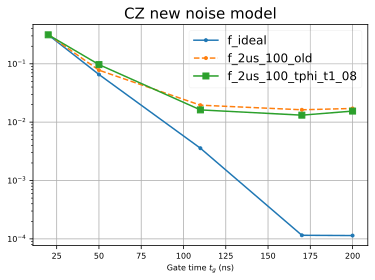

: 

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
# ax.plot(cz['tg'], 10**cz['f_1000_False'], '-',  label=r'fidelity')
ax.plot(tg5, 10**f_ideal, '.-',  label=r'f_ideal')
ax.plot(tg5, 10**f_2us_100_old, '.--',  label=r'f_2us_100_old')

# ax.plot(tg5, 10**f_2us_100_t1_08, '.-',  label=r'f_2us_100_t1_08')
# ax.plot(tg5, 10**f_2us_100_t1_28, '.-',  label=r'f_2us_100_t1_28')
# ax.plot(tg5, 10**f_2us_100_tphi, '.-',  label=r'f_2us_100_tphi')

ax.plot(tg5, 10**f_2us_100_tphi_t1_08, 's-',  label=r'f_2us_100_tphi_t1_08')
# ax.plot(tg5, 10**f_2us_100_tphi_t1_28, '^-',  label=r'f_2us_100_tphi_t1_28')

plt.yscale('log')
# plt.ylim(3e-7, 6e-1)
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'CZ new t1 model', fontsize=15)
plt.grid()
legend = plt.legend(loc='best', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [3]:
tg5 = [20, 50, 80, 110, 140, 170, 200]
f_2000_False = np.array([
-0.7463350006449967, -1.1572536044642163, -1.6055752664883682, -2.395993844715164 ,
-3.2629103625352656, -3.7905483431639198, -3.853354965234451 ,
])

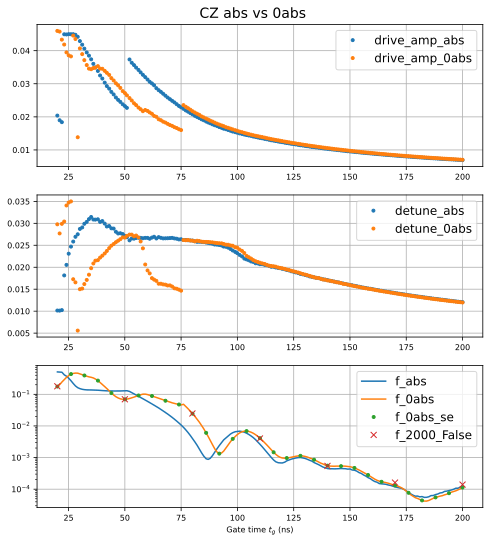

In [4]:
fig, ax = plt.subplots(figsize=(8,8), nrows=3)
fig.suptitle('CZ abs vs 0abs', fontsize=14)
fig.subplots_adjust(top=0.95)
ax[0].plot(cz_abs['tg'], cz_abs['drive_amp'], '.',  label=r'drive_amp_abs')
ax[1].plot(cz_abs['tg'], cz_abs['detune'], '.',  label=r'detune_abs')
ax[0].plot(cz['tg'], cz['drive_amp'], '.',  label=r'drive_amp_0abs')
ax[1].plot(cz['tg'], cz['detune'], '.',  label=r'detune_0abs')
ax[2].plot(cz_abs['tg'], 10**(cz_abs['f_300_1000_True']), '-',  label=r'f_abs')
ax[2].plot(cz['tg'], 10**(cz['f_1000_False']), '-',  label=r'f_0abs')
ax[2].plot(cz_se['tg'], 10**(cz_se['f_1000_False']), '.',  label=r'f_0abs_se')
ax[2].plot(tg5, 10**f_2000_False, 'x',  label=r'f_2000_False')
plt.xlabel('Gate time $t_g$ (ns)')
ax[2].set_yscale('log')
for i in range(3):
    ax[i].legend(loc='best', fontsize=12)
    ax[i].grid()

In [20]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

KeyError: 'f_300_1000_True'

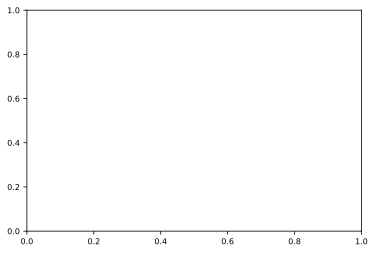

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(cz['tg'], 10**cz['f_300_1000_True'], '-',  label=r'fidelity')
ax.plot(cz_se['tg'], 10**cz_se['f_noise_9_2us'], '.--',  label=r'f_noise_9_2us')
ax.plot(cz_se['tg'], 10**cz_se['f_noise_100_5us'], '.--',  label=r'f_noise_100_5us')
ax.plot(cz_se['tg'], 10**cz_se['f_noise_100_50us'], '.--',  label=r'f_noise_100_50us')
plt.yscale('log')
# plt.ylim(3e-7, 6e-1)
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'CZ (f_$T_{\phi}^{\rm logi}$_$T_{\phi/1}^{\rm other}$)', fontsize=15)
plt.grid()
legend = plt.legend(loc='best', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
tg7 = np.array([ 20.047153,  50.072552,  80.075366, 110.014433, 140.019538, 170.026627, 200.001076])
tg6 = np.array([ 20.047153,  50.072552,  80.075366, 110.014433, 140.019538, 170.026627])

f_ideal_70 = np.array([
-0.29837929367832183, -0.9088319157086439, -2.3269390940964687, -2.56493307197575 ,
-3.387685788394828, -3.9990964673562313,
])
f_2us = np.array([
-0.2946167205422707, -0.7937941955128693, -1.178912999939339, -1.2418767057861553 ,
-1.2709606684109203, -1.2646866052597594, -1.2496614475130627 ,
])

tg_pick = np.array([ 20.047153,  110.014433, 200.001076])

f_inf_10us = np.array([-0.2982341687684872, -0.9015143971196324, -2.0914616808453896, -2.241651594121491,
                               -2.4650000738249607, -2.4876262432801672 , -2.463792815628059 ,])

f_inf_30us = np.array([-0.2983300159725927, -0.9062888999658231, -2.2313058753801176, -2.4242737974151147 ,
-2.8339191788764415, -2.915344336825855 ,])

f_inf_50us = np.array([-0.2983466736660545, -0.9072580359704131, -2.2655691086544634, -2.4723439693754097 ,
-2.970143989924972, -3.0935866183996206 ,])

f_200_50us = np.array([
-0.2983534872925094, -0.9068172481559493, -2.244314419384983, -2.4623143641647527 ,
-2.9607361337905256, -3.083861837995698 ,
])
f_100_50us = np.array([
-0.29835193270508403, -0.9071465453294557, -2.256319656782038, -2.459503604995601 ,
-2.9296735866895953, -3.0332540263316714 ,
])
f_100_10us = np.array([
-0.2982218453640895, -0.901163079011324, -2.079913875044839, -2.2020203223090498 ,
-2.396260741048805, -2.416900781633071 ,
])
f_100_5us = np.array([
-0.298080801312204, -0.8938051652977077, -1.925564710378478, -2.054515966580957 ,
-2.177677352460941, -2.1549687946653346 ,
])

f_9_2us = np.array([
-0.2977279957296213, -0.8673238083838535, -1.5616022037998507, -1.6692099774084983 ,
-1.7525811684495445, -1.763472165202698 ,
])


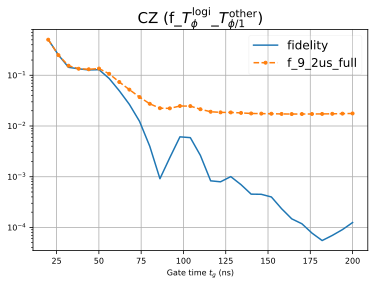

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(cz_se['tg'], 10**cz_se['f_300_1000_True'], '-',  label=r'fidelity')
# ax.plot(tg7, 10**(params[:,4]), '.-',  label=r'f_pick')
# ax.plot(tg6, 10**(f_ideal_70), '.-',  label=r'f_ideal')
# ax.plot(tg7, 10**(f_2us), 'x',  label=r'f_2us')
ax.plot(cz_se['tg'], 10**(f_9_2us_full), '.--',  label=r'f_9_2us_full')
# ax.plot(tg6, 10**(f_9_2us), 'x',  label=r'f_9_2us')
# ax.plot(tg6, 10**(f_inf_50us), '.--',  label=r'f_$\infty$_50us')
# ax.plot(tg6, 10**(f_200_50us), '.--',  label=r'f_200_50us')
# ax.plot(tg6, 10**(f_100_50us), '.--',  label=r'f_100_50us')
# ax.plot(tg6, 10**(f_100_10us), '.--',  label=r'f_100_10us')
# ax.plot(tg6, 10**(f_100_5us), '.--',  label=r'f_100_5us')
plt.yscale('log')
# plt.ylim(3e-7, 6e-1)
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'CZ (f_$T_{\phi}^{\rm logi}$_$T_{\phi/1}^{\rm other}$)', fontsize=15)
plt.grid()
legend = plt.legend(loc='best', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [ ]:
f_ideal = np.array([
-0.29837929367832194, -0.6170577378242812, -0.8422106046032803, -0.9103820450600629 ,
-0.9239023132842592, -0.9088319157086439, -1.065011199439195, -1.287994239582645 ,
-1.5322099634371855, -1.8509711373394526, -2.3269390940965, -3.0341235479127766 ,
-2.67616251433528, -2.236895427319793, -2.226808947027156, -2.564933071975662 ,
-3.0774233336192807, -3.1290636501130136, -3.0157772545079813, -3.1684229880382953 ,
-3.3876857883944744, -3.3884751172015037, -3.440537650056816, -3.6854377121516793 ,
-3.916711805487556, -3.9990964673562313, -4.194514689418508, -4.360987906975992 ,
-4.230188590868294, -4.088505478104231, -3.9359768706390494 ,
])

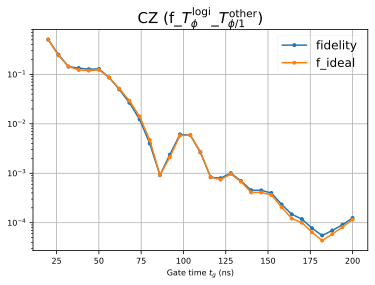

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(cz_se['tg'], 10**cz_se['f_300_1000_True'], '.-',  label=r'fidelity')
ax.plot(cz_se['tg'], 10**f_ideal, '.-',  label=r'f_ideal')

plt.yscale('log')
# plt.ylim(3e-7, 6e-1)
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'CZ (f_$T_{\phi}^{\rm logi}$_$T_{\phi/1}^{\rm other}$)', fontsize=15)
plt.grid()
legend = plt.legend(loc='best', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
tg7 = np.array([ 20.047153,  50.072552,  80.075366, 110.014433, 140.019538, 170.026627, 200.001076])
tg6 = np.array([ 20.047153,  50.072552,  80.075366, 110.014433, 140.019538, 170.026627])
f_2us_ideal_30 = np.array([
-0.3446451864493842, -0.9814319360730099, -1.6040501113060563, -1.9929039266604114 ,
-2.494010573089831, -2.6769819686737737, -2.8539187332314464 ,
])
f_2us_noise_30 = np.array([
-0.3400944654612261, -0.8599801035770576, -1.0962285699886138, -1.2120424181741611 ,
-1.266365202577231, -1.2639147380555449, -1.2520078833224737 ,
])

f_2us_ideal_50 = np.array([
-0.2902711689506291, -0.7538464302533866, -2.251268090743694, -2.5498314922696843, -3.132122575691803 ,
-3.698521479649386 , -3.803606468230306 ,
])
f_2us_noise_50 = np.array([
-0.28682662099858114, -0.6757289419632098, -1.1724084539898505, -1.2395791235716616, -1.2673626143644081 ,
-1.2630869310833652 , -1.2486943459321032 ,
])
f_ideal_70 = np.array([
-0.29837929367832183, -0.9088319157086439, -2.3269390940964687, -2.56493307197575 ,
-3.387685788394828, -3.9990964673562313, -3.9359768706390494 ,
])
f_2us = np.array([
-0.2946167205422707, -0.7937941955128693, -1.178912999939339, -1.2418767057861553 ,
-1.2709606684109203, -1.2646866052597594, -1.2496614475130627 ,
])
tg_pick = np.array([ 20.047153,  110.014433, 200.001076])

f_inf_10us = np.array([-0.2982341687684872, -0.9015143971196324, -2.0914616808453896, -2.241651594121491,
                               -2.4650000738249607, -2.4876262432801672 , -2.463792815628059 ,])

f_inf_30us = np.array([-0.2983300159725927, -0.9062888999658231, -2.2313058753801176, -2.4242737974151147 ,
-2.8339191788764415, -2.915344336825855 ,])

f_inf_50us = np.array([-0.2983466736660545, -0.9072580359704131, -2.2655691086544634, -2.4723439693754097 ,
-2.970143989924972, -3.0935866183996206 ,])

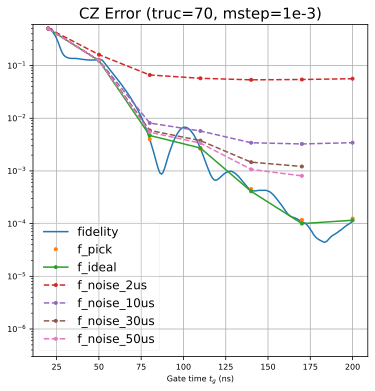

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(cz80_1ncut['tg'], 10**cz80_1ncut['f_80_400'], '-',  label=r'fidelity')
ax.plot(tg7, 10**(params[:,4]), '.',  label=r'f_pick')
ax.plot(tg7, 10**(f_ideal_70), '.-',  label=r'f_ideal')
ax.plot(tg7, 10**(f_2us), '.--',  label=r'f_noise_2us')
ax.plot(tg7, 10**(f_inf_10us), '.--',  label=r'f_noise_10us')
ax.plot(tg6, 10**(f_inf_30us), '.--',  label=r'f_noise_30us')
ax.plot(tg6, 10**(f_inf_50us), '.--',  label=r'f_noise_50us')
plt.yscale('log')
plt.ylim(3e-7, 6e-1)
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error (truc=70, mstep=1e-3)', fontsize=15)
plt.grid()
legend = plt.legend(loc='best', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

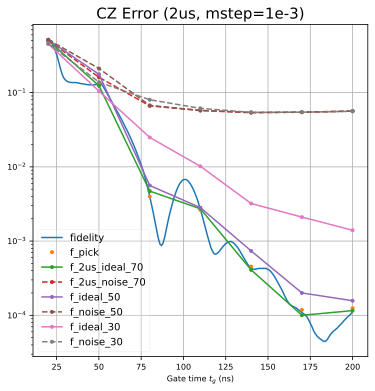

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(cz80_1ncut['tg'], 10**cz80_1ncut['f_80_400'], '-',  label=r'fidelity')
ax.plot(tg7, 10**(params[:,4]), '.',  label=r'f_pick')
ax.plot(tg7, 10**(f_ideal_70), '.-',  label=r'f_2us_ideal_70')
ax.plot(tg7, 10**(f_2us), '.--',  label=r'f_2us_noise_70')
ax.plot(tg7, 10**(f_2us_ideal_50), '.-',  label=r'f_ideal_50')
ax.plot(tg7, 10**(f_2us_noise_50), '.--',  label=r'f_noise_50')
ax.plot(tg7, 10**(f_2us_ideal_30), '.-',  label=r'f_ideal_30')
ax.plot(tg7, 10**(f_2us_noise_30), '.--',  label=r'f_noise_30')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error (2us, mstep=1e-3)', fontsize=15)
plt.grid()
legend = plt.legend(loc='best', fontsize=10)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

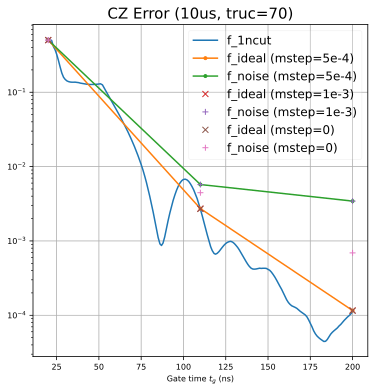

In [ ]:
tg_pick = np.array([ 20.047153,  110.014433, 200.001076])
f_10us_ideal_70_5e4 = np.array([-0.29838140288215986, -2.5648508868340816, -3.935960134115187 ,])
f_10us_noise_70_5e4 = np.array([-0.29823291100202465, -2.241170924957868, -2.463939794270056 ,])
f_10us_ideal_70_e3 = np.array([-0.29837929367832194, -2.564933071975662, -3.9359768706390494 ,])
f_10us_noise_70_e3 = np.array([-0.2982341687684872, -2.241651594121491, -2.463792815628059 ,])
f_10us_ideal_70_e0 = np.array([-0.29835618136006703,  -2.5689612630252787 , -3.936568200018096 ,])
f_10us_noise_70_e0 = np.array([-0.2988192170257969,  -2.3511142518416936 , -3.1603608491420125 ,])
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(cz80_1ncut['tg'], 10**cz80_1ncut['f_80_400'], '-',  label=r'f_1ncut')
ax.plot(tg_pick, 10**(f_10us_ideal_70_5e4), '.-',  label=r'f_ideal (mstep=5e-4)')
ax.plot(tg_pick, 10**(f_10us_noise_70_5e4), '.-',  label=r'f_noise (mstep=5e-4)')
ax.plot(tg_pick, 10**(f_10us_ideal_70_e3), 'x',  label=r'f_ideal (mstep=1e-3)')
ax.plot(tg_pick, 10**(f_10us_noise_70_e3), '+',  label=r'f_noise (mstep=1e-3)')
ax.plot(tg_pick, 10**(f_10us_ideal_70_e0), 'x',  label=r'f_ideal (mstep=0)')
ax.plot(tg_pick, 10**(f_10us_noise_70_e0), '+',  label=r'f_noise (mstep=0)')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error (10us, truc=70)', fontsize=15)
plt.grid()
legend = plt.legend(loc='best', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

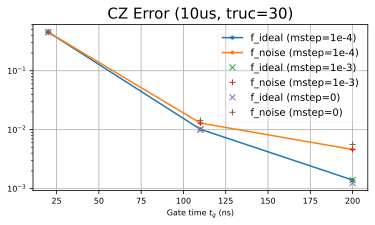

In [ ]:
f_10us_ideal_30_e4 = np.array([-0.3446444394782259, -1.9930209265473806, -2.8543820424764212 ,])
f_10us_noise_30_e4 = np.array([-0.3444398034870056, -1.8881022213237548, -2.335958711305545 ,])
f_10us_ideal_30_e3 = np.array([-0.34464518644938386, -1.9929039266604114, -2.853918733231274 ,])
f_10us_noise_30_e3 = np.array([-0.34443920463265026, -1.8880198960825427, -2.335566432914533 ,])
f_10us_ideal_30_e0 = np.array([-0.344553250004798, -2.0019244043470636, -2.9045192947016596 ,])
f_10us_noise_30_e0 = np.array([-0.34519330347982247, -1.841661351292697, -2.2505689112345895 ,])
fig, ax = plt.subplots(figsize=(6,3))
# ax.plot(cz80_1ncut['tg'], 10**cz80_1ncut['f_80_400'], '-',  label=r'f_1ncut')
ax.plot(tg_pick, 10**(f_10us_ideal_30_e4), '.-',  label=r'f_ideal (mstep=1e-4)')
ax.plot(tg_pick, 10**(f_10us_noise_30_e4), '.-',  label=r'f_noise (mstep=1e-4)',)
ax.plot(tg_pick, 10**(f_10us_ideal_30_e3), 'x',  label=r'f_ideal (mstep=1e-3)')
ax.plot(tg_pick, 10**(f_10us_noise_30_e3), '+',  label=r'f_noise (mstep=1e-3)')
ax.plot(tg_pick, 10**(f_10us_ideal_30_e0), 'x',  label=r'f_ideal (mstep=0)')
ax.plot(tg_pick, 10**(f_10us_noise_30_e0), '+',  label=r'f_noise (mstep=0)')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error (10us, truc=30)', fontsize=15)
plt.grid()
legend = plt.legend(loc='best', fontsize=10)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

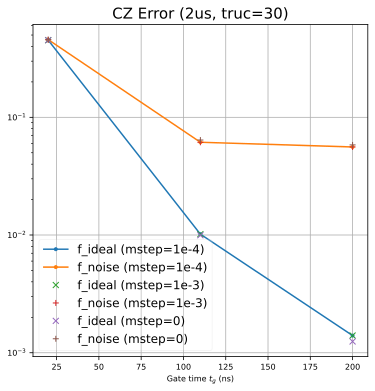

In [ ]:
tg_pick = np.array([ 20.047153,  110.014433, 200.001076])
f_2us_ideal_30_e4 = np.array([-0.3446444394782259, -1.9930209265473806, -2.8543820424764212 ,])
f_2us_noise_30_e4 = np.array([-0.3400940841687087, -1.2120413568082207, -1.2520078057326112 ,])
f_2us_ideal_30_e3 = np.array([-0.3446451864493842,  -1.9929039266604114 , -2.8539187332314464 ,])
f_2us_noise_30_e3 = np.array([-0.3400944654612261,  -1.2120424181741611 , -1.2520078833224737 ,])
f_2us_ideal_30_e0 = np.array([-0.344553250004798, -2.0019244043470636, -2.9045192947016596 ,])
f_2us_noise_30_e0 = np.array([-0.3412133866840776, -1.1932104683740339, -1.2345624076777804 ,])
fig, ax = plt.subplots(figsize=(6,6))
# ax.plot(cz80_1ncut['tg'], 10**cz80_1ncut['f_80_400'], '-',  label=r'f_1ncut')
ax.plot(tg_pick, 10**(f_2us_ideal_30_e4), '.-',  label=r'f_ideal (mstep=1e-4)')
ax.plot(tg_pick, 10**(f_2us_noise_30_e4), '.-',  label=r'f_noise (mstep=1e-4)')
ax.plot(tg_pick, 10**(f_2us_ideal_30_e3), 'x',  label=r'f_ideal (mstep=1e-3)')
ax.plot(tg_pick, 10**(f_2us_noise_30_e3), '+',  label=r'f_noise (mstep=1e-3)')
ax.plot(tg_pick, 10**(f_2us_ideal_30_e0), 'x',  label=r'f_ideal (mstep=0)')
ax.plot(tg_pick, 10**(f_2us_noise_30_e0), '+',  label=r'f_noise (mstep=0)')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error (2us, truc=30)', fontsize=15)
plt.grid()
legend = plt.legend(loc='best', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

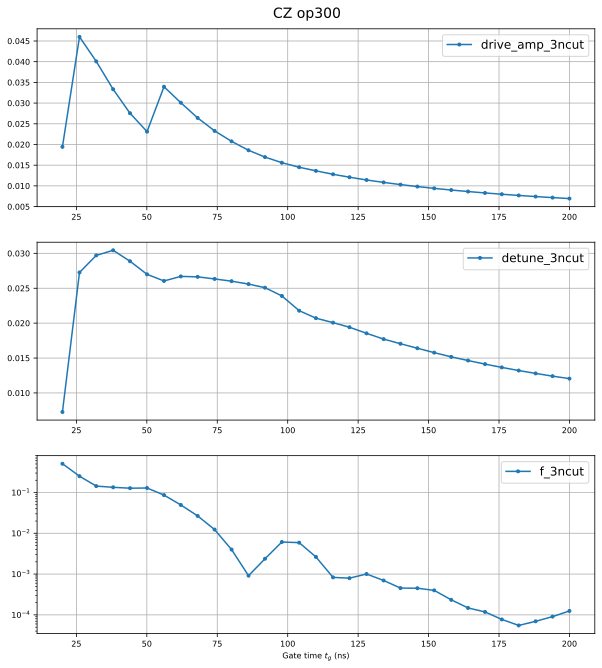

In [ ]:
fig, ax = plt.subplots(figsize=(10,10), nrows=3)
fig.suptitle('CZ op300', fontsize=14)
fig.subplots_adjust(top=0.95)
ax[0].plot(cz300_se_3ncut['tg'], cz300_se_3ncut['drive_amp'], '.-',  label=r'drive_amp_3ncut')
ax[1].plot(cz300_se_3ncut['tg'], cz300_se_3ncut['detune'], '.-',  label=r'detune_3ncut')
ax[2].plot(cz300_se_3ncut['tg'], 10**(cz300_se_3ncut['f_300_1000_True']), '.-',  label=r'f_3ncut')
# ax[2].plot(tg7, 10**(cz300_se_3ncut['f_300_1000_True']), '+',  label=r'f_3ncut')

plt.xlabel('Gate time $t_g$ (ns)')
# ax[0].set_ylim(0.04, 0.05)
# ax[1].set_ylim(0.01, 0.02)
# ax[0].set_ylim(0.0065, 0.009)
# ax[1].set_ylim(0.01, 0.02)
ax[2].set_yscale('log')
for i in range(3):
    ax[i].legend(loc='best', fontsize=12)
    ax[i].grid()
    # ax[i].set_xlim(25, 40)
    # ax[i].set_xlim(150, 200)

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
f_3ncut = np.array([
[20.077003, -0.21774820565385278] ,
[26.043284, -0.5212326955896632] ,
[31.931254, -0.6466153020883416] ,
[38.082317, -0.32399640655980155] ,
[44.061218, -0.4629831864869195] ,
[50.083415, -0.686377887422939] ,
[56.025239, -0.9231694472859718] ,
[62.092027, -1.1901955638056814] ,
[68.042765, -1.3956731194252487] ,
[73.993407, -1.624784678089285] ,
[79.985745, -1.7638947007545192] ,
[85.968536, -1.7075014122322631] ,
[92.003021, -1.531440601412357] ,
[98.095432, -1.586232364781121] ,
[104.099756, -1.7995868816796257] ,
[110.068882, -2.0348038590893025] ,
[116.094656, -2.227404569249037] ,
[121.906996, -2.3379476121871505] ,
[128.094457, -2.3935198275887712] ,
[134.008265, -2.544269854185506] ,
[140.00363, -2.6795490923039527] ,
[146.000607, -2.753568601435755] ,
[152.007024, -2.868416336878344] ,
[158.00117, -3.0042882093625547] ,
[164.004109, -3.1428575954884823] ,
[170.00114, -3.229660129800753] ,
[176.009278, -3.3414914982774913] ,
[182.001711, -3.4578949333890234] ,
[188.000168, -3.5746583571085524] ,
[194.00424, -3.534176144684229] ,
[200.006185, -3.5645434076936464] ,
])

f_3ncut_1000 = np.array([
    -0.29504637, -0.59953059, -0.84173165, -0.87265561 ,
-0.89447518, -0.88948531, -1.05961745, -1.30576516 ,
-1.57426362, -1.90544164, -2.39001144, -3.03177291 ,
-2.61503567, -2.21482826, -2.2304441, -2.58433721 ,
-3.07753285, -3.10363726, -2.99977582, -3.15514439 ,
-3.34603567, -3.35038826, -3.29251342, -3.6258575 ,
-3.82500114, -3.73024991, -4.10886854, -4.25456333 ,
-3.7673624, -4.05587445 , -3.83
])

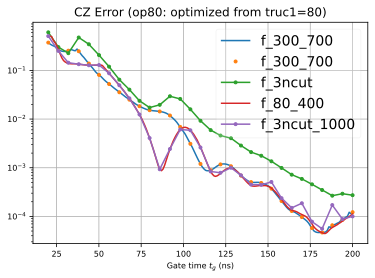

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(cz300_1ncut['tg'], 10**(cz300_1ncut['f_300_700']), '-',  label=r'f_300_700')
plt.plot(cz300_se_1ncut['tg'], 10**(cz300_se_1ncut['f_300_700']), '.',  label=r'f_300_700')
plt.plot(cz300_se_1ncut['tg'], 10**(f_3ncut[:,1]), '.-',  label=r'f_3ncut')
plt.plot(cz80_1ncut['tg'], 10**(cz80_1ncut['f_80_400']), '-',  label=r'f_80_400')
plt.plot(cz300_se_1ncut['tg'], 10**(f_3ncut_1000), '.-',  label=r'f_3ncut_1000')
# plt.plot(cz300_se['tg'], 10**(f_500_500[:,1]), 'x',  label=r'f_500_500')


plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error (op80: optimized from truc1=80)', fontsize=12)
plt.grid()
legend = plt.legend(loc='best', fontsize=14)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [ ]:
f_300_500 = np.array([
[20.077003, -0.4304431807286377] ,
[26.043284, -0.5756690927197206] ,
[31.931254, -0.5955240000503583] ,
[38.082317, -0.6033025248666004] ,
[44.061218, -0.852969475213978] ,
[50.083415, -1.0895247456810508] ,
[56.025239, -1.280796913212383] ,
[62.092027, -1.4491160667062126] ,
[68.042765, -1.600531521186606] ,
[73.993407, -1.7362673822313963] ,
[79.985745, -1.8174340396591042] ,
[85.968536, -1.8430888337431413] ,
[92.003021, -1.927252768982951] ,
[98.095432, -2.1618566684728995] ,
[104.099756, -2.5072995650284122] ,
[110.068882, -2.9184857251131167] ,
[116.094656, -3.045493281328949] ,
[121.906996, -2.9306739618653395] ,
[128.094457, -2.9685547350383916] ,
[134.008265, -3.1613014404576765] ,
[140.00363, -3.2942741176393326] ,
[146.000607, -3.3122272416787113] ,
[152.007024, -3.4290417517442284] ,
[158.00117, -3.6832402574809815] ,
[164.004109, -3.8890569981184475] ,
[170.00114, -4.018603482857845] ,
[176.009278, -4.249009094595264] ,
[182.001711, -4.348281820362137] ,
[188.000168, -4.196739488919509] ,
[194.00424, -4.080694740092048] ,
[200.006185, -3.918985706219968] ,
])

f_400_500 = np.array([
[20.077003, -0.2192835747735014] ,
[26.043284, -0.5232918357188014] ,
[31.931254, -0.6475310873990133] ,
[38.082317, -0.32283959828888475] ,
[44.061218, -0.461487715646283] ,
[50.083415, -0.6854275913722658] ,
[56.025239, -0.9225055470424302] ,
[62.092027, -1.1896931392532295] ,
[68.042765, -1.3959023471570335] ,
[73.993407, -1.625497513866311] ,
[79.985745, -1.7649918590115106] ,
[85.968536, -1.7084649029544214] ,
[92.003021, -1.5318854185993427] ,
[98.095432, -1.5864682704793875] ,
[104.099756, -1.8000780986995877] ,
[110.068882, -2.035374565839137] ,
[116.094656, -2.2286220050836016] ,
[121.906996, -2.339288915108187] ,
[128.094457, -2.394640913716861] ,
[134.008265, -2.5461319737130093] ,
[140.00363, -2.6818820115373483] ,
[146.000607, -2.757280874769845] ,
[152.007024, -2.8706888833447475] ,
[158.00117, -3.0057321143591538] ,
[164.004109, -3.144006731712669] ,
[170.00114, -3.232148278364547] ,
[176.009278, -3.3457315887986483] ,
[182.001711, -3.4609985654652586] ,
[188.000168, -3.5436836458354124] ,
[194.00424, -3.53955208416644] ,
[200.006185, -3.5708335653212946] ,
])
f_500_500 = np.array([
[20.077003, -0.21928356801907498] ,
[26.043284, -0.5232918935630284] ,
[31.931254, -0.6475314956399607] ,
[38.082317, -0.3228395868787535] ,
[44.061218, -0.4614877116726273] ,
[50.083415, -0.6854276546812796] ,
[56.025239, -0.9225057225245253] ,
[62.092027, -1.189692919189142] ,
[68.042765, -1.3959041708764879] ,
[73.993407, -1.6254948554338737] ,
[79.985745, -1.7649934829672467] ,
[85.968536, -1.708466287076133] ,
[92.003021, -1.531888602531441] ,
[98.095432, -1.5864741769412773] ,
[104.099756, -1.8000758489833324] ,
[110.068882, -2.035364200327335] ,
[116.094656, -2.2286007678261623] ,
[121.906996, -2.3392882584458343] ,
[128.094457, -2.3946441052644776] ,
[134.008265, -2.546151536888399] ,
[140.00363, -2.681919977517285] ,
[146.000607, -2.7572613195767066] ,
[152.007024, -2.870711671934364] ,
[158.00117, -3.00580103737163] ,
[164.004109, -3.1438383985939393] ,
[170.00114, -3.232314676023154] ,
[176.009278, -3.3457910850934107] ,
[182.001711, -3.4606769120571466] ,
[188.000168, -3.5438275800804075] ,
[194.00424, -3.5397352328928906] ,
[200.006185, -3.5705974059419963] ,
])

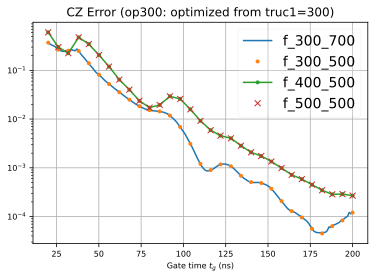

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(cz300_1ncut['tg'], 10**(cz300_1ncut['f_300_700']), '-',  label=r'f_300_700')
# plt.plot(cz300_se_v2['tg'], 10**(cz300_se_v2['f_300_700']), '.',  label=r'f_300_700')
plt.plot(cz300_se_1ncut['tg'], 10**(f_300_500[:,1]), '.',  label=r'f_300_500')
plt.plot(cz300_se_1ncut['tg'], 10**(f_400_500[:,1]), '.-',  label=r'f_400_500')
plt.plot(cz300_se_1ncut['tg'], 10**(f_500_500[:,1]), 'x',  label=r'f_500_500')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error (op300: optimized from truc1=300)', fontsize=12)
plt.grid()
legend = plt.legend(loc='best', fontsize=14)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

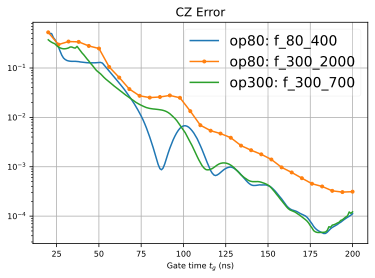

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(cz80_1ncut['tg'], 10**cz80_1ncut['f_80_400'], '-',  label=r'op80: f_80_400')
plt.plot(cz80_se['tg'], 10**cz80_se['f_300_2000'], '.-',  label=r'op80: f_300_2000')
plt.plot(cz300_1ncut['tg'], 10**(cz300_1ncut['f_300_700']), '-',  label=r'op300: f_300_700')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error', fontsize=12)
plt.grid()
legend = plt.legend(loc='best', fontsize=14)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [ ]:
f_400_500 = np.array([
[20.074749, -0.21732231391785756] ,
[26.083127, -0.5068310849616271] ,
[31.988187, -0.6492735031657489] ,
[38.08762, -0.3164819120919714] ,
[44.058392, -0.4626675916169598] ,
[50.086935, -0.6889039524047555] ,
[56.087064, -0.9407050230478031] ,
[62.091833, -1.1771180304243227] ,
[68.078194, -1.397194095894895] ,
[74.046222, -1.616922734670189] ,
[80.062878, -1.7703613340921445] ,
[86.032572, -1.7168064528375282] ,
[91.997815, -1.515231729905221] ,
[98.047029, -1.593456033269596] ,
[104.064603, -1.7690442829894246] ,
[110.088003, -2.0365921587336637] ,
[115.947545, -2.2211438184611247] ,
[121.933936, -2.327019823657786] ,
[128.082335, -2.421308704800871] ,
[134.094898, -2.5384669176404695] ,
[140.010415, -2.6917729398826933] ,
[145.916957, -2.2065939352340074] ,
[152.086256, -2.351482431315154] ,
[158.066044, -2.470331165288442] ,
[164.020744, -3.128726201095099] ,
[170.017014, -2.682156761357737] ,
[176.059985, -2.784202646389618] ,
[181.973222, -3.460257874383197] ,
[188.079439, -2.945957457420703] ,
[193.944023, -3.04713362678511] ,
[199.946739, -3.114435911723047] ,
])

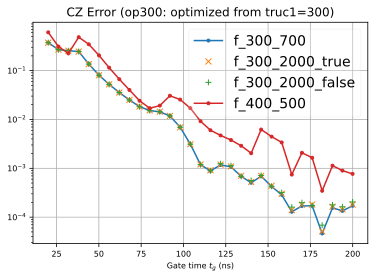

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
# plt.plot(cz300['tg'], 10**(cz300['f_300_700']), '-',  label=r'f_300_700')
plt.plot(cz300_se_1ncut['tg'], 10**(cz300_se_1ncut['f_300_700']), '.-',  label=r'f_300_700')
plt.plot(cz300_se_1ncut['tg'], 10**(cz300_se_1ncut['f_300_2000']), 'x',  label=r'f_300_2000_true')
plt.plot(cz300_se_1ncut['tg'], 10**cz300_se_1ncut['f_300_2000_false'], '+',  label=r'f_300_2000_false')
plt.plot(cz300_se_1ncut['tg'], 10**f_400_500[:,1], '.-',  label=r'f_400_500')
# plt.plot(cz80['tg'], 10**f200, '.',  label=r'f_300_200')
# plt.plot(cz80['tg'], 10**f700, 'x',  label=r'f_300_700')
# plt.plot(cz80['tg'], 10**cz80['f_80_200'], '-',  label=r'f_80_200')
# plt.plot(cz_se['tg'], 10**cz_se['f_300_2000'], '.-',  label=r'f_300_2000')
# plt.plot(cz_se['tg'], 10**cz300['f_300_2000'], '.-',  label=r'f_300_2000_new')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error (op300: optimized from truc1=300)', fontsize=12)
plt.grid()
legend = plt.legend(loc='best', fontsize=14)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [ ]:
=

In [ ]:
f_300_200 = np.array([
-0.49615128, -0.45561566, -0.39999307, -0.34195359 ,
-0.29235226, -0.34330087, -0.39113125, -0.44173915 ,
-0.49338094, -0.54524923, -0.59644954 ,
])
f_300_700 = np.array([
-0.52622892, -0.48324866, -0.42427294, -0.36336949 ,
-0.26761333, -0.3213138, -0.36998291, -0.41734865 ,
-0.46366479, -0.50888876, -0.55648623 ,
])
pa =np.array([
[27.002075, 0.044032, 0.024957] ,
[28.004505, 0.044006, 0.024969] ,
[29.001588, 0.044002, 0.025] ,
[30.001597, 0.044002, 0.02498] ,
[31.008723, 0.05, 0.004962] ,
[32.008245, 0.049922, 0.007309] ,
[33.009192, 0.048925, 0.008961] ,
[34.009908, 0.047893, 0.010034] ,
[35.006813, 0.046826, 0.011137] ,
[36.008908, 0.045742, 0.012202] ,
[37.009057, 0.044789, 0.013395] ,
])


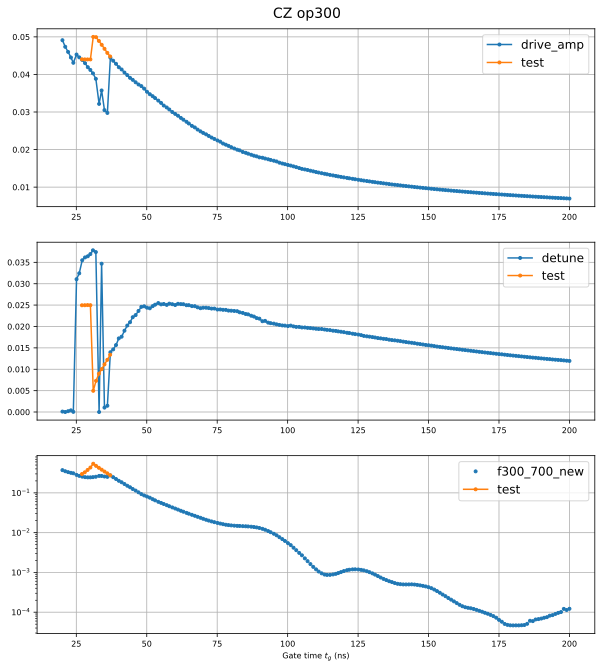

In [ ]:
fig, ax = plt.subplots(figsize=(10,10), nrows=3)
fig.suptitle('CZ op300', fontsize=14)
fig.subplots_adjust(top=0.95)
ax[0].plot(cz300_1ncut['tg'], cz300_1ncut['drive_amp'], '.-',  label=r'drive_amp')
ax[1].plot(cz300_1ncut['tg'], cz300_1ncut['detune'], '.-',  label=r'detune')
# ax[2].plot(cz300['tg'], 10**cz300['f_300_200'], '.-',  label=r'f300_200_new')
ax[2].plot(cz300_1ncut['tg'], 10**cz300_1ncut['f_300_700'], '.',  label=r'f300_700_new')
ax[0].plot(pa[:,0], pa[:,1], '.-',  label=r'test')
ax[1].plot(pa[:,0], pa[:,2], '.-',  label=r'test')
ax[2].plot(pa[:,0], 10**f_300_700, '.-',  label=r'test')


# ax[0].plot(cz['tg'], cz['drive_amp'], '.-',  label=r'drive_amp')
# ax[1].plot(cz['tg'], cz['detune'], '.-',  label=r'detune')
# ax[2].plot(cz['tg'], 10**(cz['f_200']), '.-',  label=r'fidelity_new')
plt.xlabel('Gate time $t_g$ (ns)')
# ax[0].set_ylim(0.04, 0.05)
# ax[1].set_ylim(0.01, 0.02)
# ax[0].set_ylim(0.0065, 0.009)
# ax[1].set_ylim(0.01, 0.02)
ax[2].set_yscale('log')
for i in range(3):
    ax[i].legend(loc='best', fontsize=12)
    ax[i].grid()
    # ax[i].set_xlim(25, 40)
    # ax[i].set_xlim(150, 200)

In [ ]:
print(1/(100* 2*np.pi *1e-6))
print(1/(100 *1e-6))

1591.5494309189535
10000.0


In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

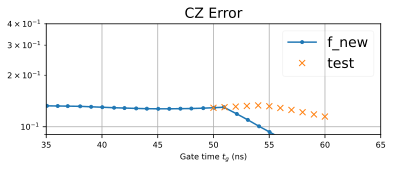

In [ ]:
fig, ax = plt.subplots(figsize=(6,2))
plt.plot(cz2['tg'], 10**(cz2['f_200']), '.-',  label=r'f_new')
# plt.plot(cz_old['tg'], 10**(cz_old['fidelity_qt']), '.-',  label=r'f_old')
plt.plot(df['tg'], 10**(df['f_200']), 'x',  label=r'test')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error', fontsize=14)
plt.grid()
ax.set_xlim(35, 65)
ax.set_ylim(9e-2, 4e-1)
# ax.set_xlim(150, 201)
legend = plt.legend(loc='best', fontsize=14)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

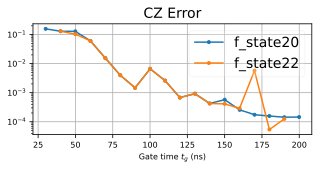

In [ ]:
f_state22 = np.array([
-0.88582615, -0.98697914, -1.21706309, -1.81364923 ,
-2.39911686, -2.83587101, -2.17886544, -2.58324798 ,
-3.16799898, -3.03628328, -3.37181672, -3.38614619 ,
-3.53888651, -2.24174523, -4.26769406, -3.90221664 ,
])
tg22 = np.arange(40, 200, 10)
fig, ax = plt.subplots(figsize=(5,2))
plt.plot(cz['tg'], 10**(cz['f_200']), '.-',  label=r'f_state20')
plt.plot(tg22, 10**f_state22, '.-',  label=r'f_state22')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error', fontsize=14)
plt.grid()
legend = plt.legend(loc='best', fontsize=14)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

### n1 vs n2

In [ ]:
f_n2_20 = pd.read_csv('data/data_fig/data_cz_n2_20.txt')
# tg_n2_22 = [40.0, 48.0, 56.0, 64.0,
#             72.0, 80.0, 88.0, 96.0,
#             104.0, 112.0, 120.0, 128.0,
#             136.0 ]
# f_n2_22 =  np.array([
# -0.8161715873390495, -1.198271187931911, -1.7594098104987108, -2.023481051551432 ,
# -2.3286657288782977, -2.7725947360658125, -2.8755953682970254, -3.1700680471833538 ,
# -3.285110444999763, -3.3547861537801977, -3.6555773638603917, -4.002191076971732 ,
# -3.756590540402148 ,
# ])
tg_n1_20 = np.linspace(40, 200, num=21)
f_n1_20 =  np.array([
-0.6788422009241489, -0.8273402721895291, -1.159557848336972, -1.5101943758724257 ,
-1.7118085090127932, -2.676954154341082, -3.0620885220467233, -3.4685087216748425 ,
-3.5305489836403576, -3.694736067684019, -3.5295116266794095, -3.4281627762740223 ,
-3.809473799225181, -4.5005631859144755, -4.5909233374599445, -4.380422006608994 ,
-4.269258022720013, -4.131695168225334, -4.030945740857079, -3.9857467419876857 ,
-4.0631473815725805
])

tg_n1_20_k11 =  np.array([
40.0, 46.0, 52.0, 58.0 ,
64.0, 70.0, 76.0, 82.0 ,
88.0, 94.0, 100.0 ,
])
f_n1_20_k11 =  np.array([
-0.6787571403170322, -0.7840224466359769, -0.9294651962067562, -1.2342476528565633 ,
-1.5101827973402506, -1.6856272710140634, -2.2678394617485584, -2.480496337914263 ,
-3.062047398026912, -3.639748542869371, -3.221233504849732 ,
])
f_n1n2_20_k11 =  np.array([
-0.6162097733444539, -0.7432477052506214, -0.8803205086353373, -1.0182339020022375 ,
-1.145297240280844, -1.346329531305885, -1.5857552068199687, -1.8706817221542356 ,
-2.170647735119183, -2.335343517287301, -2.4973221023385466 ,
])
f_n1_00 =  np.array([
-0.5886852204952149, -0.8075146729709541, -1.0559025555318895, -1.3597443049015168 ,
-1.7119339585326072, -2.6761220066673523, -3.062169162700722, -3.46838411436316 ,
-3.53024642127191, -3.6953943630513115, -3.5308950396284633, -3.428288851913472 ,
-3.809384776659836, -4.50053327654272, -4.590881985227773, -4.380360258810188 ,
-4.268406760557727, -4.131933451137084, -4.030632593363932, -3.9854147507377204 ,
-3.935447361086711 ,
])
f_n1_22 =  np.array([
-0.6787707865867112, -0.8273818922188472, -1.1595645265077459, -1.510193275231373 ,
-1.7119685420146196, -2.676852996511711, -3.0621894814669575, -3.4679151741193874 ,
-3.5306734410936795, -3.6949819355585256, -3.5308061244866837, -3.428188619388921 ,
-3.8085449164033847, -4.500466320427937, -4.591121683370864, -4.380168880773497 ,
-4.268686111804918, -4.131951251930413, -4.0311298237958475, -3.985422179901248 ,
-4.062727894619917 ,
])
tg_n1n2_20 = [40.0, 48.0, 56.0 ,]
f_n1n2_20 =  np.array([-0.616172996364993, -0.7877798870601149, -0.9729419369959393 ,])
# f_n1n2_00 =  np.array([-0.6161361703614281, -0.7877805289182075, -0.9728984513629764 ,])




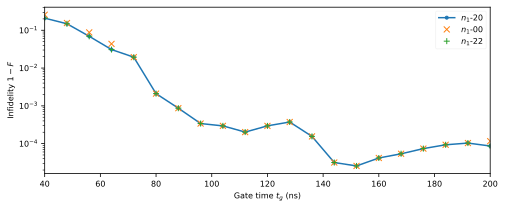

In [ ]:
fig, ax = plt.subplots(figsize=(8,3))
# plt.plot(f_n2_20['tg'], 10**f_n2_20['fidelity_qt'], '.-',  label=r'$n_2$-20')
# plt.plot(tg_n2_22, 10**f_n2_22, 'x',  label=r'$n_2$-22')
plt.plot(tg_n1_20, 10**f_n1_20, '.-', label=r'$n_1$-20')
# plt.plot(tg_n1_20_k11, 10**f_n1_20_k11, 'x', label=r'$n_1$-20-k11')
# plt.plot(tg_n1_20_k11, 10**f_n1n2_20_k11, '.-', label=r'$n_1n_2$-20-k11')
plt.plot(tg_n1_20, 10**f_n1_00, 'x', label=r'$n_1$-00')
plt.plot(tg_n1_20, 10**f_n1_22, '+', label=r'$n_1$-22')
# plt.plot(tg_n1n2_20, 10**f_n1n2_20, '.-', label=r'$n_1n_2$-20')
# plt.plot(tg_n1n2_20, 10**f_n1n2_00, 'x', label=r'$n_1n_2$-20')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.ylabel('Infidelity $1-F$')
# plt.grid()
plt.xlim(40,200)
# plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [ ]:
tg_vec = np.linspace(40, 200, num=21)

# param = np.loadtxt('data/0815/aaa.txt', delimiter=',')
f_40 =  [-0.9070845082051546, -1.2598973169220298, -1.849313479425224, -2.116756844048582,
-2.403782531642886, -2.8511412131950387, -2.9697040751011623, -3.270950576996622,
-3.4164628913980426, -4.041826216786483, -3.7768887863243155, -4.059237374862007,
-3.845976129230374, -4.213672599770272, -4.989193208162769, -4.509901945861088,
-4.460128704615228, -4.3340550458755285, -4.507361305797105, -4.489470911585019, -4.461971925164813]
f_1600_9 =  [-0.9051693670250833, -1.2541215281965623, -1.821955392485761, -2.0542721955855776,
-2.2684515512212635, -2.5128483573769076, -2.526328680501479, -2.575381270016941,
-2.6046796908219085, -2.6112251811250555, -2.5080990043267097, -2.487977868148923,
-2.4526414064027775, -2.4486309078983597, -2.4436790542026876, -2.3816708400500906,
-2.3690808838006037, -2.3444688503377913, -2.32391502201516, -2.3029017936292075, -2.285922216733808]
f_1600_100 = [
-0.9068451680149641, -1.2591930365003756, -1.8459588935092535, -2.109101779348597 ,
-2.3863203863467346, -2.797759213935785, -2.892449670293085, -3.1151200300254196 ,
-3.209972793465119, -3.455983026111865, -3.3194505021583565, -3.3739926980659485 ,
-3.2994485051201456, -3.3611336889778727, -3.4006952186505104, -3.332468601422884 ,
-3.3156069563165134, -3.2845757594306466, -3.277372951342401, -3.2570965444052784 ,
-3.2392648048466253 ,
]
inf_40 = [10**(f_40[i]) for i in range(len(f_40))]
inf_1600_9 = [10**(f_1600_9[i]) for i in range(len(f_1600_9))]
inf_1600_100 = [10**(f_1600_100[i]) for i in range(len(f_1600_100))]

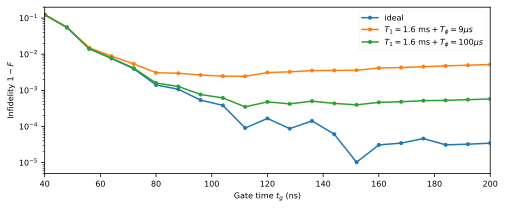

In [ ]:
fig, ax = plt.subplots(figsize=(8,3))
plt.plot(tg_vec, inf_40, '.-', color=colors[0], label=r'ideal')
plt.plot(tg_vec, inf_1600_9, '.-', color=colors[1], label=r'$T_1=1.6\ {\rm ms}+T_{\phi}=9\mu s$')
plt.plot(tg_vec, inf_1600_100, '.-', color=colors[2], label=r'$T_1=1.6\ {\rm ms}+T_{\phi}=100\mu s$')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.ylabel('Infidelity $1-F$')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [ ]:
f_dark = [
-0.7867512886745673, -0.9551963708402209, -1.1420776767573262, -1.5493438035097946 ,
-1.844010610154276, -2.3756863372014254, -2.8650409394621548, -3.2723739468972037 ,
-3.5143757812020398, -3.792153104827175, -3.7479638808557874, -3.734591322105788 ,
-3.4899611895777536, -3.5603791939172122, -4.020406620485938, -4.30131792076429 ,
-4.299283735896858, -4.718291932412348, -4.404821234286704 ,]
inf_dark = [10**(f_dark[i]) for i in range(len(f_dark))]
f_dark_correct = [
-0.5729442295730862, -0.7340924459606013, -0.9013088096394402, -1.1460086836430365 ,
-1.355531221288533, -1.452637538253877, -1.8078364038462877, -2.3802384797234093 ,
-2.4954763756068172, -3.129480716937766, -3.5249555678663325, -3.8916312978101613 ,
-3.556304412205746, -3.6021348106232898, -3.6705502487505584, -3.6652231253260728 ,
-3.678208104250878, -3.748775481544553, -3.894908359125151 ,]
inf_dark_correct = [10**(f_dark_correct[i]) for i in range(len(f_dark_correct))]

In [ ]:
# columns = ['tg', 'fidelity', 'fidelity_qt', 'detuning', 'drive_amp', 'd_eta']
# df = pd.DataFrame(para_dark2, columns=columns)
# df.to_csv('data/data_cz_n1n2_20_dark.txt', sep=',', index=False, header=True)

In [ ]:
columns = ['tg', 'fidelity', 'fidelity_qt', 'detuning', 'drive_amp']
f_cz = pd.read_csv('data/data_cz_n2_20.txt').to_numpy()
param_40 = []
param_41 = []
param_42 = []
param_44 = []
param_46 = []
for i in range(20):
    param_40.append(f_cz[8*i+0].tolist())
    param_42.append(f_cz[8*i+2].tolist())
    param_44.append(f_cz[8*i+4].tolist())
    param_46.append(f_cz[8*i+6].tolist())
param_40 = np.array(param_40)
param_42 = np.array(param_42)
param_44 = np.array(param_44)
param_46 = np.array(param_46)
for i in range(80):
    param_41.append(f_cz[2*i+1].tolist())
param_41 = np.array(param_41)


In [ ]:
f_3000_50 = np.array([
-1.0573659748319053, -1.4518658769357982, -2.004866724572045, -2.286257435207804 ,
-2.54816328853917, -3.0518798136742453, -3.2055619650565492, -2.9754678665541157 ,
-3.0231722994328836, -3.1006160611266367, -3.1039869086954015, -3.147509930727078 ,
-3.1563560637026864, -3.148857367631352, -3.1257969664381777, -3.081577430169305 ,
-3.0606960365349476, -3.039547044825624, -3.016524886574164, -2.9945874307840747 ,
])
f_1600_9 = np.array([
-1.0546849247768006, -1.4436402731946916, -1.9695384548865447, -2.2074842440961207 ,
-2.386585545238544, -2.6249916436640106, -2.636708565702304, -2.5325987047667042 ,
-2.512889261972158, -2.507522743152992, -2.49332538396722, -2.484534788643627 ,
-2.4589065405330075, -2.4397635063125427, -2.4110861826277903, -2.369213893931757 ,
-2.3467199807752865, -2.326899445412735, -2.305605088261082, -2.2871739614008657 ,
])
f_1600_inf = np.array([
-1.057915120335492, -1.4535466283539333, -2.012387962959724, -2.3042962278755166 ,
-2.59060948801512, -3.2369188145371504, -3.5649444807003876, -3.175748350379705 ,
-3.296813369851095, -3.510189407018998, -3.551258127902551, -3.752212416714567 ,
-3.932324532260614, -4.005740038413646, -4.033212319477393, -3.9791442947932856 ,
-3.974464476148602, -3.942189711808516, -3.906410328206737, -3.8565014251167553 ,
])
f_inf_9 = np.array([
-1.0547661430091686, -1.4439067916932993, -1.9706113448613576, -2.2095808671577553 ,
-2.390000810624503, -2.6314329453496392, -2.6438768224847644, -2.538666358018633 ,
-2.51917031945312, -2.5140400297670604, -2.500323277944648, -2.491891970542443 ,
-2.4661625546351886, -2.4471449814283814, -2.4182863109209563, -2.375801371088189 ,
-2.353253030737154, -2.3334530683532595, -2.3120961226395313, -2.293679252345233 ,
])
columns_dark = ['tg', 'fidelity', 'fidelity_qt', 'detuning', 'drive_amp', 'd_eta']

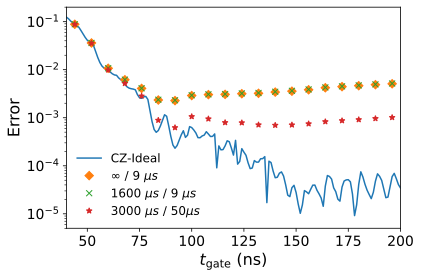

In [ ]:
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE, labelsize=BIGGER_SIZE)     # fontsize of the axes
plt.rc(['xtick', 'ytick' ], labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

fig, ax = plt.subplots(figsize=(6,4))
plt.plot(f_cz[:,0], 10**f_cz[:,2], '-', color=colors[0], label=r'CZ-Ideal')
# plt.plot(param_44[:,0], 10**param_44[:,2], '.-', color=colors[0], label=r'CNOT-Ideal')
# plt.plot(param_44[:,0], 10**f_1600_inf, '.-', color=colors[3], label=r'$1600\ \mu s\ /\ \infty$')
plt.plot(param_44[:,0], 10**f_inf_9, 'D', color=colors[1], label=r'$\infty \ /\ 9\ \mu s$')
plt.plot(param_44[:,0], 10**f_1600_9, 'x', color=colors[2], label=r'$1600\ \mu s\ /\ 9\ \mu s$')
plt.plot(param_44[:,0], 10**f_3000_50, '*', color=colors[3], label=r'$3000\ \mu s\ /\ 50\mu s$')

plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='lower left')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.savefig('image/cz_error-vs-tg.png', dpi=300, bbox_inches='tight')


In [ ]:
f_dark_1600_9 = np.array([
-1.181869026846921, -1.6002934513435612, -2.143804433875458, -2.4597448880419366 ,
-2.62877878625774, -2.6402254899592488, -2.6568170457474407, -2.605302818521059 ,
-2.590357810634136, -2.545152339842838, -2.5075544540162573, -2.4948646867445365 ,
-2.4544546022457547, -2.431054142877603, -2.4109866582631008, -2.3707119783301973 ,
-2.3680681972671094, -2.3257767615337746, -2.3284537506199, -2.302244148558135 ,
])

f_dark2_1600_9 = np.array([
-1.0209004694853765, -1.2127535382344241, -1.3077729018802497, -1.2869131632894737 ,
-1.2556396099181864, -1.216601101490664, -1.181773645785523, -1.1457353266188643 ,
-1.1246956785577127, -1.0921986737840128, -1.0660729932763284, -1.0460980560027433 ,
-1.0232267321376218, -1.00421275609436, -0.9872030004301335, -0.9664264334493061 ,
-0.9550561231047586, -0.9354290218468009, -0.9263209696542967, -0.9114130950430218 ,
])

f_dark_100_0_gamma23 = np.array([
-1.1786068695698706, -1.5876303166552106, -2.099297342718124, -2.397705052466336 ,
-2.5354050392985346, -2.536992069875457, -2.5647836982036685, -2.564702751889363 ,
-2.541010777714606, -2.6498897815245877, -2.6512369927141006, -2.6314367463741837 ,
-2.6254535800397987, -2.4901494124913226, -2.589577872738631, -2.5796252150734795 ,
-2.5584570093508816, -2.5617114522769695, -2.531515171597609, -2.519018613829867 ,
])

f_dark_3000_50 = np.array([
-1.1859710297018904, -1.6133670384521213, -2.203194447442735, -2.6380806629813063 ,
-2.974254765550469, -3.0922242603604815, -3.277819038720722, -3.2652574332456634 ,
-3.190974484008638, -3.2249272240065356, -3.198629970479388, -3.2162822762806007 ,
-3.1614631672199835, -3.143560129117952, -3.125815942203839, -3.0924839366016137 ,
-3.0839195438294293, -3.047962456820806, -3.0481542601141296, -3.027648727972774 ,
])
param2 = []
for i in range(20):
    param2.append(f_cz[8*i+4].tolist())
para = np.array(param2)
# para

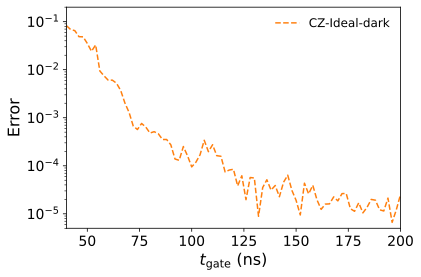

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
# plt.plot(params[:,0], 10**params[:,2], '-', color=colors[0], label=r'CZ-Ideal')
# plt.plot(param_44[:,0], 10**f_1600_9, '+', color=colors[4], label=r'$1600\ \mu s\ /\ 9\ \mu s$')
# plt.plot(param_44[:,0], 10**f_3000_50, 'D', color=colors[5], label=r'$3000\ \mu s\ /\ 50\mu s$')

plt.plot(f_cz_dark[:,0], 10**f_cz_dark[:,2], '--', color=colors[1], label=r'CZ-Ideal-dark')
# plt.plot(para[:,0], 10**f_dark_1600_9, 'x', color=colors[2], label=r'ZL:$1600\ \mu s\ /\ 9\ \mu s$')
# plt.plot(para[:,0], 10**f_dark2_1600_9, 'D', color=colors[2], label=r'$1600\ \mu s\ /\ 9\ \mu s$')
# plt.plot(para[:,0], 10**f_dark_3000_50, '*', color=colors[3], label=r'$3000\ \mu s\ /\ 50\ \mu s$ - dark')
# tg = 200
# g = 0.75
# plt.axhline(y= g*tg/1000e3, color='b', linestyle='--')
# plt.axhline(y= g*tg/100e3, color='b', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
# plt.title(f'Fit: g={g}')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


In [ ]:
# f_dark_0_10_oplist = np.array([
# -1.1784362457627657, -1.600930668984733, -2.0910552380818146, -2.391529650812574 ,
# -2.5123092700542933, -2.5774328607434054, -2.747860120060501, -2.7444228678118594 ,
# -2.44528550897792, -2.3963701992210416, -2.34711162068442, -2.349784889172325 ,
# -2.2885213096791386, -2.6251330496005196, -2.243725246199628, -2.28521336496759 ,
# -2.194081434222072, -2.2393311277560537, -2.1422947422203316, -2.1674151595969184 ,
# ])

# f_dark_0_100_oplist = np.array([
# -1.1861028720661115, -1.6149712588274288, -2.2038229569460697, -2.6533364495318357 ,
# -3.003171288578587, -3.1733377022555302, -3.5368118342529806, -3.598781373209999 ,
# -3.2691861455507647, -3.328943077686961, -3.2950072826112975, -3.3410988507883665 ,
# -3.259049834085927, -3.576725468025104, -3.224309124642154, -3.2701687450668464 ,
# -3.1757627064197114, -3.2246540577381966, -3.1288357487516922, -3.1607641312458132 ,


In [ ]:
f_dark_1000_0_0gamma23 = np.array([
-1.1867666703025175, -1.6159325323152438, -2.2156341861776006, -2.6834044997576054 ,
-3.0910512513102777, -3.284777366151496, -3.701483352288329, -3.793148391040039 ,
-3.565080587909601, -3.794103825570761, -3.8108541862560865, -3.967145126800921 ,
-3.8414923764749735, -3.8743986293283683, -3.8426525120046593, -3.860174310923478 ,
-3.8053501132332004, -3.8187484694217537, -3.7910333138225702, -3.8119484733640427 ,
])

f_dark_1000_0_10gamma23 = np.array([
-1.1861025621768044, -1.6135375481552099, -2.2049190495875743, -2.6522898468541545 ,
-3.010286616303303, -3.1489021059353535, -3.399204623376329, -3.4432124181059978 ,
-3.330969857903929, -3.53361479500762, -3.5518082740924406, -3.611299094045365 ,
-3.562830502444493, -3.4516616388952324, -3.5490042816478886, -3.5535170880401816 ,
-3.5199719883961995, -3.5352084630592344, -3.5038694677614726, -3.5075554812842467 ,
])

f_dark_1000_0_100gamma23 = np.array([
-1.1801770891883931, -1.5925917631480195, -2.118078151469134, -2.441698170125981 ,
-2.6066546697385493, -2.6144791124181834, -2.6572332345408145, -2.6669353058903758 ,
-2.653357054385383, -2.828019135636401, -2.847276252919296, -2.8330830021922617 ,
-2.8401013874684584, -2.632001723887316, -2.813249640845993, -2.8074527932259055 ,
-2.7914662952842155, -2.808510415000504, -2.774063560584427, -2.763477728821953 ,
])

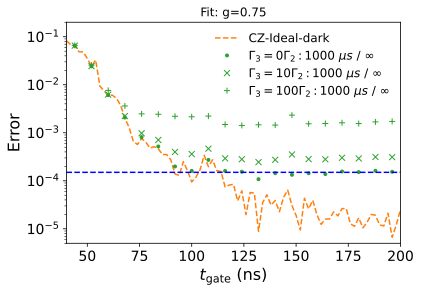

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(f_cz_dark[:,0], 10**f_cz_dark[:,2], '--', color=colors[1], label=r'CZ-Ideal-dark')
plt.plot(para[:,0], 10**f_dark_1000_0_0gamma23, '.', color=colors[2], label=r'$\Gamma_3=0\Gamma_2:1000\ \mu s\ /\ \infty$')
plt.plot(para[:,0], 10**f_dark_1000_0_10gamma23, 'x', color=colors[2], label=r'$\Gamma_3=10\Gamma_2:1000\ \mu s\ /\ \infty$')
plt.plot(para[:,0], 10**f_dark_1000_0_100gamma23, '+', color=colors[2], label=r'$\Gamma_3=100\Gamma_2:1000\ \mu s\ /\ \infty$')

tg = 200
g = 0.75
plt.axhline(y= g*tg/1000e3, color='b', linestyle='--')
# plt.axhline(y= g*tg/100e3, color='b', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
plt.title(f'Fit: g={g}')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


In [ ]:
#################################
f_dark_1000_0_oplist = np.array([
-1.1867666703025175, -1.6159325323152438, -2.2156341861776006, -2.6834044997576054 ,
-3.0910512513102777, -3.284777366151496, -3.701483352288329, -3.793148391040039 ,
-3.565080587909601, -3.794103825570761, -3.8108541862560865, -3.967145126800921 ,
-3.8414923764749735, -3.8743986293283683, -3.8426525120046593, -3.860174310923478 ,
-3.8053501132332004, -3.8187484694217537, -3.7910333138225702, -3.8119484733640427 ,
])
#################################
f_dark_100_0_oplist = np.array([
-1.1851703255298667, -1.6106890332813526, -2.1922032100779036, -2.609184724066303 ,
-2.9021013799991193, -3.0022498932626815, -3.141117703049448, -3.1342754867143148 ,
-3.031637574923834, -3.0384116164721235, -3.014644216745796, -3.01000603681934 ,
-2.970851886449323, -2.9839405002874484, -2.9276847269059427, -2.915537640435693 ,
-2.8839131882682922, -2.8718147320823757, -2.8468497367554746, -2.8357080411009776 ,
])

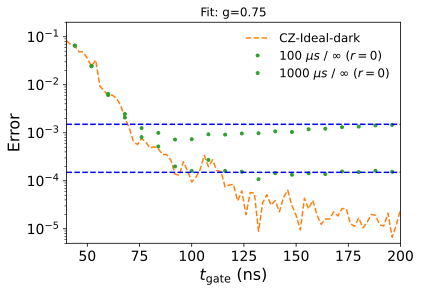

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(f_cz_dark[:,0], 10**f_cz_dark[:,2], '--', color=colors[1], label=r'CZ-Ideal-dark')
plt.plot(para[:,0], 10**f_dark_100_0_oplist, '.', color=colors[2], label=r'$100\ \mu s\ /\ \infty\ (r=0)$')
plt.plot(para[:,0], 10**f_dark_1000_0_oplist, '.', color=colors[2], label=r'$1000\ \mu s\ /\ \infty\ (r=0)$')
tg = 200
g = 0.75
plt.axhline(y= g*tg/1000e3, color='b', linestyle='--')
plt.axhline(y= g*tg/100e3, color='b', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
plt.title(f'Fit: g={g}')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


In [ ]:
f_0_10_r0 = np.array([ # ratio = 0
-1.077453019382125, -1.3023297050739404, -1.9386429390089854, -2.099539254215521 ,
-2.274225254291767, -2.307016353632379, -2.371651082262373, -2.22083056747898 ,
-2.4285954683429636, -2.405766363042772, -2.1234530559994496, -2.038930018591436 ,
-1.9920063539195916, -2.3453019953551313, -1.9951230934635003, -1.9479360531463579 ,
-1.9199803590919562, -1.9041817191969181, -1.89871104147584, -1.886463818238399 ,
])

f_0_100_r0 = np.array([
-1.08335186409443, -1.3151509578661753, -2.016939944440978, -2.2611051339128823 ,
-2.950458102076347, -3.042451306719301, -3.1840099852728536, -3.080151672698599 ,
-3.300382470400138, -3.289820581227957, -3.0782242651492444, -3.011298560180331 ,
-2.9681827138855454, -3.306730518859775, -2.9887675002549416, -2.9375735247277825 ,
-2.909669313871294, -2.8961302433059792, -2.8913014944794644, -2.8797183510838495 ,
])

f_1600_50_r0 = np.array([
-1.0826133946716379, -1.3135510667406884, -2.0065785282589386, -2.2380951936426836 ,
-2.7963157570008152, -2.8652743483752934, -2.984253428694135, -2.838898101125046 ,
-3.0351160584658086, -3.039847657208591, -2.7860677631635307, -2.710488440127052 ,
-2.6655430881848066, -2.9994158867165197, -2.674921460605465, -2.626748940431045 ,
-2.5997942065611865, -2.5835608563455814, -2.5791141860478657, -2.566851420825501 ,
])

f_1600_50_r10 = np.array([
-1.0645790073480201, -1.2761453153646654, -1.8259627688964384, -1.934526633493299 ,
-2.107595959743552, -2.1234162894063697, -2.1250158295854233, -2.094449400924085 ,
-2.102412382409353, -2.085464664185565, -2.20581608552785, -2.161033902955939 ,
-2.1590230702634745, -2.046890325643061, -2.0702682466870987, -2.080256421605017 ,
-2.100158064852972, -2.0386611629813656, -2.0871100096115867, -2.0800728919545284 ,
])

f_1600_50_r100 = np.array([
-0.9330594464786695, -1.0445471980149625, -1.22941496761878, -1.2218594389657957 ,
-1.254509238730096, -1.262880836529637, -1.247914675925693, -1.2222544082190447 ,
-1.219524375578926, -1.207083187655578, -1.3308642540235915, -1.2716034275997512 ,
-1.2844939860746518, -1.1951552306165354, -1.1751955957247897, -1.2003870684550577 ,
-1.2369303472255846, -1.162577170522272, -1.2354525491886006, -1.2339690924016935 ,
])



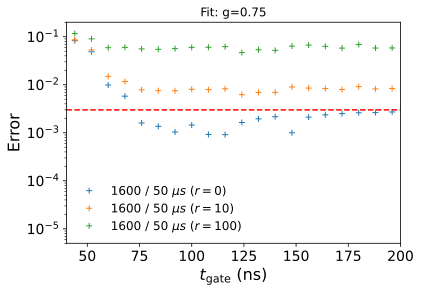

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
# plt.plot(para_dark[:,0], 10**para_dark[:,2], '--', color=colors[1], label=r'CZ-Ideal-dark')
plt.plot(para[:,0], 10**f_1600_50_r0, '+', color=colors[0], label=r'$1600\ /\ 50\ \mu s\ (r=0)$')
plt.plot(para[:,0], 10**f_1600_50_r10, '+', color=colors[1], label=r'$1600\ /\ 50\ \mu s\ (r=10)$')
plt.plot(para[:,0], 10**f_1600_50_r100, '+', color=colors[2], label=r'$1600\ /\ 50\ \mu s\ (r=100)$')
tg = 200
g = 0.75
plt.axhline(y=g * tg/50e3, color='r', linestyle='--')
# plt.axhline(y=g * tg/10e3, color='r', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
plt.title(f'Fit: g={g}')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


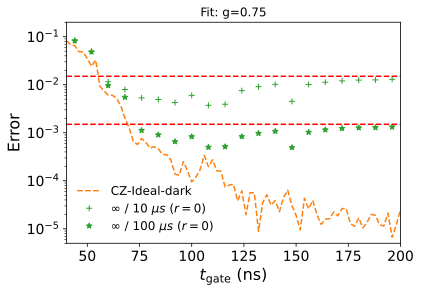

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(f_cz_dark[:,0], 10**f_cz_dark[:,2], '--', color=colors[1], label=r'CZ-Ideal-dark')
plt.plot(para[:,0], 10**f_0_10_r0, '+', color=colors[2], label=r'$\infty\ /\ 10\ \mu s\ (r=0)$')
plt.plot(para[:,0], 10**f_0_100_r0, '*', color=colors[2], label=r'$\infty\ /\ 100\ \mu s\ (r=0)$')
tg = 200
g = 0.75
plt.axhline(y=g * tg/100e3, color='r', linestyle='--')
plt.axhline(y=g * tg/10e3, color='r', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
plt.title(f'Fit: g={g}')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


In [ ]:
f_1600_9_r0 = np.array([
-1.0766694718850158, -1.300640806913398, -1.9291267119254742, -2.0823071759521454 ,
-2.2321392199623076, -2.2632696663027176, -2.2589753112958366, -2.1743051631392065 ,
-2.380616316118754, -2.358289817185083, -2.075811129480029, -1.9915637541240978 ,
-1.9447155990112757, -2.2947842584462403, -1.9472834702227946, -1.9003311161204193 ,
-1.8723533268527544, -1.856435419981659, -1.8509637224104998, -1.8386808684825098 ,
])

f_1600_9_r0_tg44 = np.array([
-1.1682295397597806, -1.5822925641191392, -1.9728660075325322, -2.1832192516185884 ,
-2.2281293843938004, -2.2735254810370353, -2.4170823974638513, -2.4072026462626352 ,
-2.1112952567597496, -2.05382758625602, -2.0038268914075834, -2.003537858736673 ,
-1.9451908231626964, -2.2769403496213747, -1.8977898997523648, -1.9391996376068439 ,
-1.8483990849244611, -1.8905926714647203, -1.7966729265082253, -1.8196415720648196 ,
])

f_1600_100_r0_tg44 = np.array([
-1.1851322362779273, -1.613018537750157, -2.188158507075542, -2.6126100893370077 ,
-2.9015194305962373, -3.028613752030297, -3.29649013987716, -3.3491340729169154 ,
-3.0348187617938236, -3.037649807679861, -2.9960121976524494, -3.015651516712926 ,
-2.947827978153804, -3.2508189670852636, -2.9066116040327024, -2.9467481629300236 ,
-2.8576246292641656, -2.9010339128867613, -2.808480693690277, -2.834156330971088 ,
])

f_1600_100_r10_tg44 = np.array([
-1.1740720924578332, -1.5724089171764415, -2.049673953486879, -2.302741480731999 ,
-2.3809620737466384, -2.383919502461643, -2.3928576153807364, -2.41538386810818 ,
-2.3389597510265445, -2.4533969467222887, -2.4634581440290972, -2.431716582409807 ,
-2.4369398386215653, -2.3152794523886087, -2.394171412122901, -2.4148054897373314 ,
-2.3622549398483677, -2.4059821979426004, -2.3376944945552895, -2.3347946695931965 ,
])

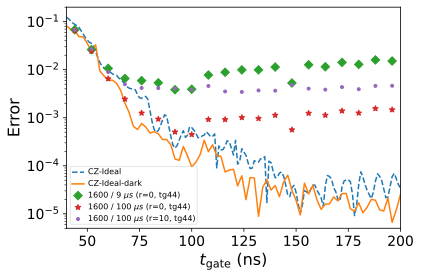

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(f_cz[:,0], 10**f_cz[:,2], '--', color=colors[0], label=r'CZ-Ideal')
plt.plot(f_cz_dark[:,0], 10**f_cz_dark[:,2], '-', color=colors[1], label=r'CZ-Ideal-dark')
# plt.plot(para[:,0], 10**f_1600_9_r0, '*', color=colors[1], label=r'$1600\ /\ 9\ \mu s$')
plt.plot(para[:,0], 10**f_1600_9_r0_tg44, 'D', color=colors[2], label=r'$1600\ /\ 9\ \mu s$ (r=0, tg44)')
plt.plot(para[:,0], 10**f_1600_100_r0_tg44, '*', color=colors[3], label=r'$1600\ /\ 100\ \mu s$ (r=0, tg44)')
plt.plot(para[:,0], 10**f_1600_100_r10_tg44, '.', color=colors[4], label=r'$1600\ /\ 100\ \mu s$ (r=10, tg44)')
# plt.plot(para[:,0], 10**f_1600_50_r0, '.', color=colors[4], label=r'$1600\ /\ 9\ \mu s$')
tg = 200
g = 0.75
# plt.axhline(y=g * tg/9e3, color='r', linestyle='--')
# plt.axhline(y=g * tg/100e3, color='r', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
# plt.title(f'Fit: g={g}')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(
    loc="best",
    frameon=True,
    handlelength=1.5,
    handletextpad=0.5,
    handleheight=0.01,
    borderpad=0.2, fontsize=8,
)
legend.get_frame().set_alpha(0.5)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


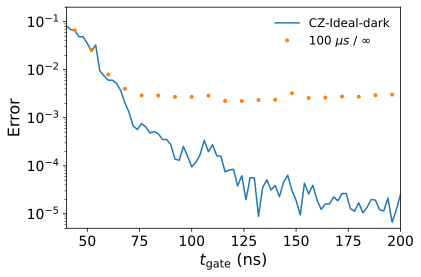

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
# plt.plot(params[:,0], 10**params[:,2], '--', color=colors[0], label=r'CZ-Ideal')
# plt.plot(param_44[:,0], 10**f_1600_9, '+', color=colors[4], label=r'$1600\ \mu s\ /\ 9\ \mu s$')
# plt.plot(param_44[:,0], 10**f_3000_50, 'D', color=colors[5], label=r'$3000\ \mu s\ /\ 50\mu s$')

plt.plot(f_cz_dark[:,0], 10**f_cz_dark[:,2], color=colors[0], label=r'CZ-Ideal-dark')

plt.plot(para[:,0], 10**f_dark_100_0_gamma23, '.', color=colors[1], label=r'$100\ \mu s\ /\ \infty$')
# plt.plot(para[:,0], 10**f_dark_1000_0_gamma23, 'D', color=colors[2], label=r'$1000\ \mu s\ /\ \infty$')

plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


In [ ]:
gamma_2 =  1/100e3
gamma_p2 = 0/9e3
gamma_3 =  gamma_2*10
gamma_p3 =  gamma_p2*0
gamma_t1 = [0, gamma_3, gamma_2] + [gamma_3]*(10-3)
gamma_t1

[0, 0.0001, 1e-05, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001]

In [ ]:
# para_42_p60 = np.hstack((tg_42.reshape(40, 1), np.round(f_42_p60.reshape(40, 1), 8), np.round(drive_param_42_p60, 8)))
# para_42_p40 = np.hstack((tg_42.reshape(40, 1), np.round(f_42_p40.reshape(40, 1), 8), np.round(drive_param_42_p40, 8)))

# para_42 = []
# for i in range(40):
#     if para_42_p60[i,1] < para_42_p40[i,1]:
#         para_42.append(para_42_p60[i].tolist())
#     else:
#         para_42.append(para_42_p40[i].tolist())
# para_42

# para_combine = np.vstack((para_40, para_41, para_42, para_44))
# para_combine = para_combine[para_combine[:, 0].argsort()]
# para_combine = np.hstack((para_combine, np.reshape(np.round(f_ideal,8), (161, 1))))
# para_combine = np.hstack((para_combine[:,0:2],
#                           para_combine[:,4].reshape(161,1),
#                           para_combine[:,2:4],))
# para_combine

In [ ]:
cz300_1ncut = np.array([
[40.007198, 0.035001, 0.029991] ,
[41.000144, 0.035008, 0.029975] ,
[41.997613, 0.035002, 0.029994] ,
[43.009503, 0.035003, 0.029921] ,
[43.997533, 0.043647, 0.025003] ,
[45.007614, 0.042915, 0.025173] ,
[46.005583, 0.042417, 0.02506] ,
[47.009543, 0.041278, 0.02505] ,
[48.00402, 0.04049, 0.02513] ,
[49.009083, 0.039826, 0.025387] ,
[50.001587, 0.03904, 0.025943] ,
[50.995011, 0.038207, 0.025878] ,
[52.003522, 0.037343, 0.026312] ,
])
f_200 = np.array([
-0.72596182, -0.65967124, -0.60394613, -0.55897519 ,
-0.55171931, -0.60874255, -0.66406911, -0.71564562 ,
-0.76228861, -0.80557203, -0.84524912, -0.88398725 ,
-0.9216978 ,
])
f_400= np.array([
-0.71637386, -0.65115176, -0.59615577, -0.55159961 ,
-0.5464498, -0.60047455, -0.65409922, -0.69366719 ,
-0.73602347, -0.77850207, -0.81912684, -0.85659746 ,
-0.89726214 ,
])
df = np.column_stack((cz300_1ncut, f_200, f_400))
df = pd.DataFrame(df, columns=['tg', 'drive_amp', 'detune', 'f_200', 'f_400'])
# df.to_csv('data/data_cz_fidelity_sesolve_v5.txt', sep=',', index=False, header=True)

In [ ]:
cz300_1ncut = np.array([
[49.998302, 0.023138, 0.027042] ,
[50.993956, 0.022512, 0.026799] ,
[51.994512, 0.021982, 0.02616] ,
[52.99411, 0.021527, 0.025138] ,
[54.009232, 0.021044, 0.024279] ,
[55.00856, 0.020954, 0.020169] ,
[55.997691, 0.020704, 0.020178] ,
[56.993415, 0.01995, 0.020062] ,
[57.992107, 0.020035, 0.020033] ,
[59.007447, 0.019728, 0.020014] ,
[59.993728, 0.019274, 0.020002] ,
])
f_200 = np.array([
-0.88918227, -0.88579022, -0.88242863, -0.87841464 ,
-0.87545935, -0.88012625, -0.89040674, -0.90175106 ,
-0.91516807, -0.92798981, -0.94053806 ,
])
f_400= np.array([
-0.88922454, -0.88581078, -0.88240595, -0.87835857 ,
-0.87537698, -0.88001829, -0.89030164, -0.90168828 ,
-0.91508011, -0.92795163, -0.94051896 ,
])
df = np.column_stack((cz300_1ncut, f_200, f_400))
df = pd.DataFrame(df, columns=['tg', 'drive_amp', 'detune', 'f_200', 'f_400'])
# df.to_csv('data/data_cz_fidelity_sesolve_v5.txt', sep=',', index=False, header=True)

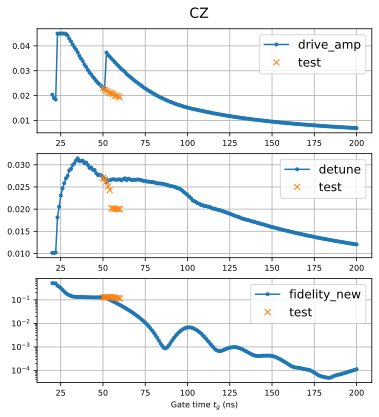

In [ ]:
fig, ax = plt.subplots(figsize=(6,6), nrows=3)
fig.suptitle('CZ', fontsize=14)
fig.subplots_adjust(top=0.93)
ax[0].plot(cz2['tg'], cz2['drive_amp'], '.-',  label=r'drive_amp')
ax[0].plot(df['tg'], df['drive_amp'], 'x',  label=r'test')
ax[1].plot(cz2['tg'], cz2['detune'], '.-',  label=r'detune')
ax[1].plot(df['tg'], df['detune'], 'x',  label=r'test')
ax[2].plot(cz2['tg'], 10**(cz2['f_200']), '.-',  label=r'fidelity_new')
# ax[2].plot(cz2['tg'], 10**(cz2['f_400']), '.-',  label=r'fidelity_new_400')
# plt.plot(cz_old['tg'], 10**(cz_old['fidelity_qt']), '.-',  label=r'fidelity_old')
ax[2].plot(df['tg'], 10**(df['f_200']), 'x',  label=r'test')
plt.xlabel('Gate time $t_g$ (ns)')
# ax[0].set_ylim(0.0065, 0.011)
# ax[1].set_ylim(0.011, 0.025)
ax[2].set_yscale('log')
for i in range(3):
    ax[i].legend(loc='best', fontsize=12)
    ax[i].grid()
    # ax[i].set_xlim(30, 70)
    # ax[i].set_xlim(150, 201)